In [15]:


import os, json, random, math, time
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"



LSTM_WEIGHTS = MODELS_DIR / "lstm_modelB_best_state_dict.pth"
LSTM_X = MODELS_DIR / "modelB_X.npy"
LSTM_y = MODELS_DIR / "modelB_y.npy"
LSTM_harp = MODELS_DIR / "modelB_harp_ids.npy"
FEAT_MEAN = MODELS_DIR / "modelB_feat_mean.npy"
FEAT_STD  = MODELS_DIR / "modelB_feat_std.npy"
FEAT_COLS = MODELS_DIR / "modelB_feature_cols.json"
CNN_CHECKPOINTS = [
    MODELS_DIR / "solar_cnn_checkpoint.pth",
    ROOT / "solar_cnn_best_auc_cpu_grouped.pth",
    MODELS_DIR / "solar_cnn_model_full.pth"
]
CNN_CSV = ROOT / "final_cnn_dataset.csv"
SHARP_PQ = DATA_DIR / "sharp_metadata_labeled.parquet"
GOES_CSV = ROOT / "goes_events_HEK.csv"
NOAA_MAP = ROOT / "noaa_to_harp_mapping.csv"

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# sanity existence checks
required = [LSTM_WEIGHTS, LSTM_X, LSTM_y, LSTM_harp, FEAT_MEAN, FEAT_STD, FEAT_COLS, CNN_CSV, SHARP_PQ, GOES_CSV, NOAA_MAP]
for p in required:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")
# find CNN checkpoint
CNN_WEIGHTS = None
for c in CNN_CHECKPOINTS:
    if c.exists():
        CNN_WEIGHTS = c
        break
if CNN_WEIGHTS is None:
    raise FileNotFoundError("No CNN checkpoint found at expected locations.")

print("Using CNN checkpoint:", CNN_WEIGHTS)


Device: cpu
Using CNN checkpoint: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\solar_cnn_checkpoint.pth


In [2]:
# Cell B: reconstruct mapping from sequence index -> (HARPNUM, t_end)
# This mirrors the sequence build used when creating modelB_X.npy
df_sharp = pd.read_parquet(SHARP_PQ)
df_goes = pd.read_csv(GOES_CSV)
map_df = pd.read_csv(NOAA_MAP)

# standardize times
df_sharp["T_REC"] = pd.to_datetime(df_sharp["T_REC"], utc=True)
df_goes.columns = [c.lower() for c in df_goes.columns]
if "peaktime" in df_goes.columns:
    df_goes["peaktime"] = pd.to_datetime(df_goes["peaktime"], utc=True)
# parse noaa_list
import ast
def safe_parse_list(x):
    try:
        if pd.isna(x): return []
        return list(ast.literal_eval(str(x)))
    except Exception:
        s = str(x).strip("[] ")
        if s=="":
            return []
        return [i.strip().strip("'\"") for i in s.split(",") if i.strip()!='']
if "noaa_list" in df_goes.columns:
    df_goes["noaa_list_parsed"] = df_goes["noaa_list"].apply(safe_parse_list)
else:
    col = next((c for c in df_goes.columns if "noaa" in c), None)
    df_goes["noaa_list_parsed"] = df_goes.get(col, []).apply(safe_parse_list)

# build noaa->harp mapping
map_df.columns = [c.strip().upper() for c in map_df.columns]
if "NOAA_AR" in map_df.columns and "HARPNUM" in map_df.columns:
    map_df2 = map_df[["NOAA_AR","HARPNUM"]].dropna().astype(int)
else:
    map_df2 = map_df.iloc[:, :2].copy().astype(int); map_df2.columns = ["NOAA_AR","HARPNUM"]
noaa_to_harp = map_df2.groupby("NOAA_AR")["HARPNUM"].apply(list).to_dict()

# build flaring_harps set
from collections import defaultdict
goes_by_harp = defaultdict(list)
for _, r in df_goes.iterrows():
    pt = r.get("peaktime", None)
    if pd.isna(pt) or pt is None:
        continue
    for s in r["noaa_list_parsed"]:
        try:
            n = int(s)
        except:
            continue
        for h in noaa_to_harp.get(n, []):
            goes_by_harp[int(h)].append(pd.Timestamp(pt))
for h in goes_by_harp:
    goes_by_harp[h] = sorted(goes_by_harp[h])
flaring_harps = sorted(list(goes_by_harp.keys()))
all_harps = sorted(df_sharp["HARPNUM"].unique())
quiet_harps = [h for h in all_harps if h not in flaring_harps]

# replicate selected_quiet sampling exactly as Model B (seeded)
random.seed(SEED)
nsel = min(len(quiet_harps), len(flaring_harps))
selected_quiet = sorted(random.sample(quiet_harps, nsel))

print("Flaring HARPS:", len(flaring_harps), "Selected quiet:", len(selected_quiet))

# Now iterate in the same order used earlier: sorted(flaring_harps) then sorted(selected_quiet)
SEQ_LEN = 120
seq_to_harp_time = []   # list of tuples (harp, t_end)
for harp in sorted(flaring_harps):
    g = df_sharp[df_sharp["HARPNUM"] == harp].sort_values("T_REC")
    if len(g) <= SEQ_LEN: 
        continue
    times = g["T_REC"].values
    for i in range(len(g) - SEQ_LEN):
        t_end = pd.Timestamp(times[i + SEQ_LEN - 1])
        seq_to_harp_time.append((int(harp), t_end))
for harp in sorted(selected_quiet):
    g = df_sharp[df_sharp["HARPNUM"] == harp].sort_values("T_REC")
    if len(g) <= SEQ_LEN: 
        continue
    times = g["T_REC"].values
    for i in range(len(g) - SEQ_LEN):
        t_end = pd.Timestamp(times[i + SEQ_LEN - 1])
        seq_to_harp_time.append((int(harp), t_end))

print("Reconstructed sequence count:", len(seq_to_harp_time))

# load X/y and check length matches
X = np.load(LSTM_X, allow_pickle=False)
y = np.load(LSTM_y, allow_pickle=False)
harp_ids = np.load(LSTM_harp, allow_pickle=False)
print("LSTM arrays shapes:", X.shape, y.shape, harp_ids.shape)

if len(seq_to_harp_time) != X.shape[0]:
    raise RuntimeError(f"Sequence count mismatch! reconstructed {len(seq_to_harp_time)} vs X {X.shape[0]}. Aborting.")
print("Mapping reconstructed and matches X ordering.")


Flaring HARPS: 53 Selected quiet: 53
Reconstructed sequence count: 91821
LSTM arrays shapes: (91821, 120, 9) (91821,) (91821,)
Mapping reconstructed and matches X ordering.


In [19]:


import os, json, random, math
from pathlib import Path
import numpy as np, pandas as pd
from collections import defaultdict
import torch
from torch.utils.data import Dataset, DataLoader

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
CNN_ARR_DIR = ROOT / "data" / "cnn_arrays"
CNN_IMAGES_PATH = CNN_ARR_DIR / "cnn_images.npy"
CNN_INDEX_PATH  = CNN_ARR_DIR / "cnn_index.npy"

LSTM_X = ROOT / "models" / "modelB_X.npy"
LSTM_Y = ROOT / "models" / "modelB_y.npy"
LSTM_HARP = ROOT / "models" / "modelB_harp_ids.npy"
SHARP_PQ = ROOT / "data" / "sharp_metadata_labeled.parquet"

SEQ_LEN = 120
MAX_LAG_MINUTES = 15
BATCH = 16


print("Loading arrays...")
cnn_index = np.load(CNN_INDEX_PATH, allow_pickle=True)
cnn_images = np.load(CNN_IMAGES_PATH, allow_pickle=True)

# Convert 2D string array to DataFrame
index_df = pd.DataFrame(cnn_index)


index_df.columns = ["HARPNUM", "TIMESTAMP_STR"]

# Parse the specific format '20100501_012400'
index_df["T_REC"] = pd.to_datetime(index_df["TIMESTAMP_STR"], format='%Y%m%d_%H%M%S', errors='coerce')
index_df["T_REC"] = index_df["T_REC"].dt.tz_localize("UTC")
index_df["HARPNUM"] = index_df["HARPNUM"].astype(int)

print("cnn_images shape:", cnn_images.shape)
print("Index sample after parsing:")
display(index_df.head(5))


df_sharp = pd.read_parquet(SHARP_PQ)
df_sharp["T_REC"] = pd.to_datetime(df_sharp["T_REC"], utc=True)

seq_to_harp_time = []
unique_harps = sorted(df_sharp["HARPNUM"].unique())
for harp in unique_harps:
    g = df_sharp[df_sharp["HARPNUM"] == harp].sort_values("T_REC")
    if len(g) <= SEQ_LEN: continue
    times = g["T_REC"].values
    for i in range(len(g) - SEQ_LEN):
        t_end = pd.Timestamp(times[i + SEQ_LEN - 1])
        if t_end.tzinfo is None: t_end = t_end.tz_localize("UTC")
        seq_to_harp_time.append((int(harp), t_end))

X = np.load(LSTM_X, allow_pickle=False)
min_seq = min(len(seq_to_harp_time), X.shape[0])
print(f"Reconstructed {len(seq_to_harp_time)} sequences. Matching first {min_seq}.")


cnn_lookup_by_harp = defaultdict(list)
for idx, row in index_df.iterrows():
    if pd.isna(row["T_REC"]): continue
    cnn_lookup_by_harp[int(row["HARPNUM"])].append((row["T_REC"], int(idx)))

for h in cnn_lookup_by_harp:
    cnn_lookup_by_harp[h].sort()

from bisect import bisect_right
tol = pd.Timedelta(minutes=MAX_LAG_MINUTES)
matched_pairs = []
missing = 0

for seq_idx in range(min_seq):
    harp, t_end = seq_to_harp_time[seq_idx]
    if harp not in cnn_lookup_by_harp:
        matched_pairs.append((seq_idx, -1)); missing += 1; continue
    
    arr = cnn_lookup_by_harp[harp]
    times = [a[0] for a in arr]
    
    # Nearest prior logic
    pos = bisect_right(times, t_end) - 1
    if pos >= 0:
        cand_time, cand_idx = arr[pos]
        if (t_end - cand_time) <= tol:
            matched_pairs.append((seq_idx, cand_idx))
        else:
            matched_pairs.append((seq_idx, -1)); missing += 1
    else:
        matched_pairs.append((seq_idx, -1)); missing += 1

usable = [(a,b) for a,b in matched_pairs if b != -1]
print(f"Usable matched pairs: {len(usable)} / {min_seq} (Missing: {missing})")


class CombinedDatasetFromNpy(Dataset):
    def __init__(self, X_array, y_array, matched_pairs, cnn_images):
        self.X = X_array
        self.y = y_array
        self.pairs = matched_pairs
        self.cnn_images = cnn_images

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        seq_idx, cnn_idx = self.pairs[i]
        meta_seq = self.X[seq_idx]
        
        # Transpose image from (H, W, C) to (C, H, W) if necessary
        img = self.cnn_images[cnn_idx]
        if img.shape[-1] == 3:
            img = np.transpose(img, (2, 0, 1))
            
        label = float(self.y[seq_idx])
        return torch.from_numpy(meta_seq).float(), torch.from_numpy(img).float(), torch.tensor(label, dtype=torch.float32)

y = np.load(LSTM_Y, allow_pickle=False)
combined_ds = CombinedDatasetFromNpy(X, y, usable, cnn_images)

if len(combined_ds) > 0:
    loader = DataLoader(combined_ds, batch_size=BATCH, shuffle=True)
    meta, img, lab = next(iter(loader))
    print("\nExample batch shapes:")
    print(f"Meta (LSTM): {meta.shape} | Img (CNN): {img.shape} | Label: {lab.shape}")

# Save results
OUT_MATCH = ROOT / "models" / "matched_seq_to_cnn_pairs.npy"
np.save(OUT_MATCH, np.array(usable, dtype=np.int64))
print("\nSaved matched pairs to:", OUT_MATCH)

Loading arrays...
cnn_images shape: (4737, 128, 128, 3)
Index sample after parsing:


,HARPNUM,TIMESTAMP_STR,T_REC
0,2,20100501_012400,2010-05-01 01:24:00+00:00
1,2,20100501_032400,2010-05-01 03:24:00+00:00
2,8,20100504_184800,2010-05-04 18:48:00+00:00
3,8,20100504_204800,2010-05-04 20:48:00+00:00
4,8,20100504_224800,2010-05-04 22:48:00+00:00


Reconstructed 2159906 sequences. Matching first 91821.
Usable matched pairs: 646 / 91821 (Missing: 91175)

Example batch shapes:
Meta (LSTM): torch.Size([16, 120, 9]) | Img (CNN): torch.Size([16, 3, 128, 128]) | Label: torch.Size([16])

Saved matched pairs to: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\matched_seq_to_cnn_pairs.npy


In [23]:
# Diagnostic A: basic stats for matched fusion pairs and label consistency
import numpy as np, pandas as pd
from pathlib import Path
ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")


CNN_IMAGES = ROOT / "data" / "cnn_arrays" / "cnn_images.npy"
CNN_INDEX  = ROOT / "data" / "cnn_arrays" / "cnn_index.npy"
MATCHED    = ROOT / "models" / "matched_seq_to_cnn_pairs.npy"
LSTM_X     = ROOT / "models" / "modelB_X.npy"
LSTM_Y     = ROOT / "models" / "modelB_y.npy"
CNN_CSV    = ROOT / "final_cnn_dataset.csv"   # optional, used for comparison

for p in [CNN_IMAGES, CNN_INDEX, MATCHED, LSTM_X, LSTM_Y]:
    print(p, "exists?", p.exists())

# load
cnn_images = np.load(CNN_IMAGES, allow_pickle=True)
cnn_index  = np.load(CNN_INDEX, allow_pickle=True)
matched    = np.load(MATCHED, allow_pickle=True)
X = np.load(LSTM_X, allow_pickle=False)
y = np.load(LSTM_Y, allow_pickle=False)

print("\nShapes:")
print(" cnn_images:", cnn_images.shape)
print(" cnn_index:", getattr(cnn_index,'shape', type(cnn_index)))
print(" matched:", matched.shape)
print(" X (LSTM):", X.shape)
print(" y (LSTM):", y.shape)

# build seq_idx, cnn_idx, labels (from LSTM y)
matched = np.asarray(matched)
seq_idx = matched[:,0].astype(int)
cnn_idx = matched[:,1].astype(int)
labels_from_seq = y[seq_idx].astype(int)

print("\nMatched pairs summary:")
print(" total matched pairs:", len(seq_idx))
print(" label counts (from LSTM y):")
unique, counts = np.unique(labels_from_seq, return_counts=True)
print(dict(zip(unique, counts)))

# check LSTM X for NaNs
n_nan_X = np.isnan(X).sum()
print("\nLSTM X NaNs total:", int(n_nan_X), "  (shape: {})".format(X.shape))

# check cnn_images for NaNs/inf
n_nan_img = np.isnan(cnn_images).sum()
n_inf_img = np.isinf(cnn_images).sum()
print("CNN images NaNs:", int(n_nan_img), " Infs:", int(n_inf_img))


if CNN_CSV.exists():
    df_cnn = pd.read_csv(CNN_CSV)
    # Try to figure columns
    time_col = next((c for c in df_cnn.columns if c.upper() in ("T_REC","T_REC_DT","T_REC_DT","T_REC_DT")), None)
    harp_col = next((c for c in df_cnn.columns if c.lower()=="harpnum"), None)
    label_col = next((c for c in df_cnn.columns if "label" in c.lower()), None)
    print("\nfinal_cnn_dataset.csv loaded: rows", len(df_cnn), "time_col:", time_col, "harp_col:", harp_col, "label_col:", label_col)
 
    label_from_csv = []
    for i, ci in enumerate(cnn_idx):
 
        found = None
        if "fits_Br" in df_cnn.columns:
 
            entry = cnn_index[ci]
     
            try:
           
                if time_col in df_cnn.columns:

                    t = None
                    if isinstance(entry, (list, tuple, np.ndarray)) and len(entry) >= 2:
                        t = str(entry[1])
                    elif isinstance(entry, dict) and ("T_REC" in entry or "TIMESTAMP_STR" in entry):
                        t = str(entry.get("T_REC") or entry.get("TIMESTAMP_STR"))
                    if t is not None:
                        # find rows where string appears (best-effort)
                        mask = df_cnn[time_col].astype(str).str.contains(t, na=False)
                        if mask.any():
                            found = df_cnn[mask].iloc[0][label_col] if label_col in df_cnn.columns else None
                # fallback: try matching HARPNUM if present
                if found is None and harp_col in df_cnn.columns:
                    entry_h = None
                    if isinstance(entry, (list, tuple, np.ndarray)) and len(entry) >= 1:
                        entry_h = int(entry[0])
                    elif isinstance(entry, dict):
                        entry_h = int(entry.get("HARPNUM", entry.get("harpnum", None)))
                    if entry_h is not None:
                        dfsub = df_cnn[df_cnn[harp_col] == int(entry_h)]
                        if len(dfsub) > 0:
                            # choose nearest time if time_col exists
                            if time_col in df_cnn.columns and "T_REC" in entry:
                                dfsub[time_col] = pd.to_datetime(dfsub[time_col], errors="coerce")
                                try:
                                    t0 = pd.to_datetime(entry.get("T_REC") or entry.get("TIMESTAMP_STR"))
                                    idxmin = (dfsub[time_col] - t0).abs().idxmin()
                                    found = dfsub.loc[idxmin, label_col] if label_col in dfsub.columns else None
                                except Exception:
                                    found = dfsub.iloc[0][label_col] if label_col in dfsub.columns else None
                            else:
                                found = dfsub.iloc[0][label_col] if label_col in dfsub.columns else None
            except Exception:
                found = None
        label_from_csv.append(found)
    n_known = sum(1 for v in label_from_csv if v is not None)
    print("Label values recovered from final_cnn_dataset.csv for cnn_idx in matched pairs: ", n_known, "/", len(cnn_idx))
    # Compare numeric equality where both known
    equal_count = 0
    compare_n = 0
    for i, v in enumerate(label_from_csv):
        if v is None: continue
        compare_n += 1
        try:
            v_int = int(v)
        except:
            continue
        if v_int == int(labels_from_seq[i]):
            equal_count += 1
    print("Where CSV label known, matches LSTM-seq label:", equal_count, "/", compare_n)

else:
    print("\nNo final_cnn_dataset.csv found — skipping CSV compare.")

print("\nDiagnostic A complete.")


C:\Users\Owner\Onedrive\Desktop\solar_proj\data\cnn_arrays\cnn_images.npy exists? True
C:\Users\Owner\Onedrive\Desktop\solar_proj\data\cnn_arrays\cnn_index.npy exists? True
C:\Users\Owner\Onedrive\Desktop\solar_proj\models\matched_seq_to_cnn_pairs.npy exists? True
C:\Users\Owner\Onedrive\Desktop\solar_proj\models\modelB_X.npy exists? True
C:\Users\Owner\Onedrive\Desktop\solar_proj\models\modelB_y.npy exists? True

Shapes:
 cnn_images: (4737, 128, 128, 3)
 cnn_index: (4737, 2)
 matched: (646, 2)
 X (LSTM): (91821, 120, 9)
 y (LSTM): (91821,)

Matched pairs summary:
 total matched pairs: 646
 label counts (from LSTM y):
{np.int64(0): np.int64(553), np.int64(1): np.int64(93)}

LSTM X NaNs total: 39498   (shape: (91821, 120, 9))
CNN images NaNs: 0  Infs: 0

final_cnn_dataset.csv loaded: rows 4737 time_col: T_REC harp_col: HARPNUM label_col: label_MX_24h
Label values recovered from final_cnn_dataset.csv for cnn_idx in matched pairs:  646 / 646
Where CSV label known, matches LSTM-seq label: 

In [24]:

import numpy as np, pandas as pd
from pathlib import Path
ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")

CNN_INDEX  = ROOT / "data" / "cnn_arrays" / "cnn_index.npy"
MATCHED    = ROOT / "models" / "matched_seq_to_cnn_pairs.npy"
SHARP_PQ   = ROOT / "data" / "sharp_metadata_labeled.parquet"
LSTM_X     = ROOT / "models" / "modelB_X.npy"
LSTM_Y     = ROOT / "models" / "modelB_y.npy"

cnn_index = np.load(CNN_INDEX, allow_pickle=True)
matched = np.load(MATCHED, allow_pickle=True)
matched = np.asarray(matched)
seq_idx = matched[:,0].astype(int)
cnn_idx = matched[:,1].astype(int)
X = np.load(LSTM_X, allow_pickle=False)
y = np.load(LSTM_Y, allow_pickle=False)


df_sharp = pd.read_parquet(SHARP_PQ)
df_sharp["T_REC"] = pd.to_datetime(df_sharp["T_REC"], utc=True)

SEQ_LEN = X.shape[1]
seq_to_harp_time = []
seq_to_harp_harp = []
unique_harps = sorted(df_sharp["HARPNUM"].unique())
for harp in unique_harps:
    g = df_sharp[df_sharp["HARPNUM"] == harp].sort_values("T_REC")
    if len(g) <= SEQ_LEN: continue
    times = g["T_REC"].values
    for i in range(len(g) - SEQ_LEN):
        t_end = pd.Timestamp(times[i + SEQ_LEN - 1])
        if t_end.tzinfo is None: t_end = t_end.tz_localize("UTC")
        seq_to_harp_time.append(t_end)
        seq_to_harp_harp.append(int(harp))

# For speed, make arrays
seq_to_harp_time = np.array(seq_to_harp_time)
seq_to_harp_harp = np.array(seq_to_harp_harp)

# Helper to extract time from cnn_index entry
def extract_time_from_index_entry(entry):
    # common entry formats: (HARPNUM, 'YYYYmmdd_HHMMSS') or structured arrays
    try:
        if isinstance(entry, (list, tuple, np.ndarray)) and len(entry) >= 2:
            t = entry[1]
            return pd.to_datetime(t, errors="coerce").tz_localize("UTC") if pd.notna(t) and pd.isna(pd.to_datetime(t, errors="coerce").tz) else pd.to_datetime(t, errors="coerce")
        elif isinstance(entry, dict):
            if "T_REC" in entry: return pd.to_datetime(entry["T_REC"], errors="coerce").tz_localize("UTC")
            if "TIMESTAMP_STR" in entry: return pd.to_datetime(entry["TIMESTAMP_STR"], format='%Y%m%d_%H%M%S', errors="coerce").tz_localize("UTC")
            # try any datetime-like field
            for k,v in entry.items():
                if "time" in k.lower() or "t_rec" in k.lower():
                    return pd.to_datetime(v, errors="coerce").tz_localize("UTC")
    except Exception:
        pass
    return pd.NaT

# compute timedeltas for matched pairs
time_diffs = []
harp_mismatch = 0
for s_i, c_i in zip(seq_idx, cnn_idx):
    if s_i >= len(seq_to_harp_time):
        time_diffs.append(np.nan); continue
    seq_time = seq_to_harp_time[s_i]
    seq_harp = seq_to_harp_harp[s_i]
    entry = cnn_index[c_i]
    # entry may be structured
    try:
        # try tuple-like
        cnn_time = extract_time_from_index_entry(entry)
        # get harp from entry if possible
        cnn_harp = None
        try:
            if isinstance(entry, (list, tuple, np.ndarray)) and len(entry) >= 1:
                cnn_harp = int(entry[0])
            elif isinstance(entry, dict):
                cnn_harp = int(entry.get("HARPNUM") or entry.get("harpnum") or entry.get("HARP"))
        except Exception:
            cnn_harp = None
    except Exception:
        cnn_time = pd.NaT
        cnn_harp = None
    if cnn_harp is not None and cnn_harp != seq_harp:
        harp_mismatch += 1
    if pd.isna(cnn_time):
        time_diffs.append(np.nan)
    else:
        td = (seq_time - cnn_time).total_seconds() / 60.0   # minutes (positive = seq after image)
        time_diffs.append(td)

td_arr = np.array(time_diffs, dtype=float)
print("Time diffs (minutes) stats (seq_time - cnn_time):")
print(" count non-NaN:", np.sum(~np.isnan(td_arr)))
print(" min:", np.nanmin(td_arr), "median:", np.nanmedian(td_arr), "mean:", np.nanmean(td_arr), "max:", np.nanmax(td_arr))
print(" HARPNUM mismatch count (where cnn index HARPNUM != seq HARPNUM, best-effort):", harp_mismatch)

# show histogram buckets
valid = td_arr[~np.isnan(td_arr)]
bins = [-np.inf, -60, -15, 0, 15, 60, 180, 360, np.inf]
labels = ["<-60m","-60:-15","-15:0","0:15","15:60","60:180","180:360",">360m"]
import numpy as np
counts, _ = np.histogram(valid, bins=bins)
print("\nTime difference buckets (minutes):")
for lab,c in zip(labels, counts):
    print(f" {lab:>8} : {c}")

# show up to 10 example rows with large time diffs or NaT
print("\nExamples (seq_idx, seq_harp, seq_time, cnn_idx, cnn_harp, cnn_time, label):")
examples = []
for i, (s_i, c_i) in enumerate(zip(seq_idx, cnn_idx)):
    if i >= 200: break
    seq_time = seq_to_harp_time[s_i] if s_i < len(seq_to_harp_time) else pd.NaT
    entry = cnn_index[c_i]
    cnn_time = extract_time_from_index_entry(entry)
    cnn_harp = None
    try:
        if isinstance(entry, (list, tuple, np.ndarray)) and len(entry)>=1:
            cnn_harp = int(entry[0])
        elif isinstance(entry, dict):
            cnn_harp = int(entry.get("HARPNUM") or entry.get("harpnum") or entry.get("HARP"))
    except:
        cnn_harp = None
    td = (seq_time - cnn_time).total_seconds()/60.0 if (pd.notna(seq_time) and pd.notna(cnn_time)) else np.nan
    examples.append((s_i, int(seq_to_harp_harp[s_i]) if s_i < len(seq_to_harp_harp) else None, seq_time, c_i, cnn_harp, cnn_time, int(y[s_i]), td))

# show worst mismatches (largest positive diff) and a few negative ones
examples_df = pd.DataFrame(examples, columns=["seq_idx","seq_harp","seq_time","cnn_idx","cnn_harp","cnn_time","label","td_min"])
examples_df_sorted = examples_df.sort_values("td_min", ascending=False)
display(examples_df_sorted.head(10))
display(examples_df_sorted.tail(10))

print("\nDiagnostic B complete.")


Time diffs (minutes) stats (seq_time - cnn_time):
 count non-NaN: 0
 min: nan median: nan mean: nan max: nan
 HARPNUM mismatch count (where cnn index HARPNUM != seq HARPNUM, best-effort): 0

Time difference buckets (minutes):
    <-60m : 0
  -60:-15 : 0
    -15:0 : 0
     0:15 : 0
    15:60 : 0
   60:180 : 0
  180:360 : 0
    >360m : 0

Examples (seq_idx, seq_harp, seq_time, cnn_idx, cnn_harp, cnn_time, label):


C:\Users\Owner\AppData\Local\Temp\ipykernel_19220\1382992229.py:97: RuntimeWarning: All-NaN slice encountered
  print(" min:", np.nanmin(td_arr), "median:", np.nanmedian(td_arr), "mean:", np.nanmean(td_arr), "max:", np.nanmax(td_arr))
C:\Users\Owner\AppData\Local\Temp\ipykernel_19220\1382992229.py:97: RuntimeWarning: Mean of empty slice
  print(" min:", np.nanmin(td_arr), "median:", np.nanmedian(td_arr), "mean:", np.nanmean(td_arr), "max:", np.nanmax(td_arr))


,seq_idx,seq_harp,seq_time,cnn_idx,cnn_harp,cnn_time,label,td_min
0,1964,8,2010-05-04 18:48:00+00:00,2,8,NaT,0,NaN
1,1965,8,2010-05-04 19:00:00+00:00,2,8,NaT,0,NaN
2,1973,8,2010-05-04 20:48:00+00:00,3,8,NaT,0,NaN
3,1974,8,2010-05-04 21:00:00+00:00,3,8,NaT,0,NaN
4,1980,8,2010-05-04 22:48:00+00:00,4,8,NaT,0,NaN
5,1981,8,2010-05-04 23:00:00+00:00,4,8,NaT,0,NaN
6,1999,8,2010-05-05 02:36:00+00:00,5,8,NaT,0,NaN
7,2000,8,2010-05-05 02:48:00+00:00,5,8,NaT,0,NaN
8,2009,8,2010-05-05 04:36:00+00:00,6,8,NaT,0,NaN
9,2010,8,2010-05-05 04:48:00+00:00,6,8,NaT,0,NaN


,seq_idx,seq_harp,seq_time,cnn_idx,cnn_harp,cnn_time,label,td_min
190,25812,92,2010-07-26 04:24:00+00:00,111,92,NaT,0,NaN
191,25818,92,2010-07-26 05:36:00+00:00,112,92,NaT,0,NaN
192,25819,92,2010-07-26 05:48:00+00:00,112,92,NaT,0,NaN
193,25826,92,2010-07-26 07:36:00+00:00,113,92,NaT,0,NaN
194,25827,92,2010-07-26 07:48:00+00:00,113,92,NaT,0,NaN
195,25836,92,2010-07-26 09:36:00+00:00,114,92,NaT,0,NaN
196,25837,92,2010-07-26 09:48:00+00:00,114,92,NaT,0,NaN
197,25838,92,2010-07-26 10:24:00+00:00,115,92,NaT,0,NaN
198,25839,92,2010-07-26 10:36:00+00:00,115,92,NaT,0,NaN
199,25848,92,2010-07-26 12:24:00+00:00,116,92,NaT,0,NaN



Diagnostic B complete.


In [32]:
# FINAL fixed cell — robust parsing, normalize all times to tz-aware UTC, compute diffs, show examples
import numpy as np
import pandas as pd
from pathlib import Path
import dateutil.parser as dparser

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")

CNN_INDEX  = ROOT / "data" / "cnn_arrays" / "cnn_index.npy"
MATCHED    = ROOT / "models" / "matched_seq_to_cnn_pairs.npy"
SHARP_PQ   = ROOT / "data" / "sharp_metadata_labeled.parquet"
LSTM_X     = ROOT / "models" / "modelB_X.npy"
LSTM_Y     = ROOT / "models" / "modelB_y.npy"
CNN_CSV    = ROOT / "final_cnn_dataset.csv"


cnn_index = np.load(CNN_INDEX, allow_pickle=True)
matched = np.load(MATCHED, allow_pickle=True)
matched = np.asarray(matched)
seq_idx = matched[:,0].astype(int)
cnn_idx = matched[:,1].astype(int)
X = np.load(LSTM_X, allow_pickle=False)
y = np.load(LSTM_Y, allow_pickle=False)


df_sharp = pd.read_parquet(SHARP_PQ)
df_sharp["T_REC"] = pd.to_datetime(df_sharp["T_REC"], errors="coerce")

SEQ_LEN = X.shape[1]
seq_to_harp_time = []
seq_to_harp_harp = []
unique_harps = sorted(df_sharp["HARPNUM"].unique())
for harp in unique_harps:
    g = df_sharp[df_sharp["HARPNUM"] == harp].sort_values("T_REC")
    if len(g) <= SEQ_LEN:
        continue
    times = g["T_REC"].values
    for i in range(len(g) - SEQ_LEN):
        t_end = pd.Timestamp(times[i + SEQ_LEN - 1])
        if t_end.tzinfo is None:
            t_end = t_end.tz_localize("UTC")
        else:
            t_end = t_end.tz_convert("UTC")
        seq_to_harp_time.append(t_end)
        seq_to_harp_harp.append(int(harp))

seq_to_harp_time = np.array(seq_to_harp_time, dtype=object)
seq_to_harp_harp = np.array(seq_to_harp_harp, dtype=int)

def parse_cnn_index_time(entry):
    try:
        if isinstance(entry, (list, tuple, np.ndarray)) and len(entry) >= 2:
            ts = entry[1]
            if isinstance(ts, bytes): ts = ts.decode("utf-8")
            if isinstance(ts, str):
                ts = ts.strip()
                for fmt in ("%Y%m%d_%H%M%S", "%Y%m%d_%H%M", "%Y-%m-%d %H:%M:%S%z", "%Y-%m-%d %H:%M:%S"):
                    try:
                        return pd.to_datetime(ts, format=fmt, errors="raise")
                    except: pass
                try:
                    return pd.Timestamp(dparser.parse(ts))
                except: pass
        if isinstance(entry, dict):
            for k in ("T_REC", "TIMESTAMP_STR", "timestamp", "time", "t_rec"):
                if k in entry and entry[k] is not None:
                    return parse_cnn_index_time((None, entry[k]))
    except: pass
    return pd.NaT

rows = []
for i, e in enumerate(cnn_index):
    harp = None
    try:
        if isinstance(e, (list, tuple, np.ndarray)) and len(e) >= 1:
            harp = int(e[0])
        elif isinstance(e, dict):
            harp = int(e.get("HARPNUM") or e.get("harpnum") or e.get("HARP", -1))
    except: harp = None
    t = parse_cnn_index_time(e)
    rows.append({"cnn_idx": int(i), "harp": harp, "cnn_time_raw": t, "raw": e})

index_df = pd.DataFrame(rows)
index_df["cnn_time"] = pd.to_datetime(index_df["cnn_time_raw"], utc=True, errors="coerce")

print("Parsed cnn_index sample (first 12 rows):")
display(index_df.head(12))


time_diffs = []
harp_mismatch = 0
nan_ct = 0
tds = []

for s_i, c_i in zip(seq_idx, cnn_idx):
    if s_i >= len(seq_to_harp_time):
        time_diffs.append(np.nan); nan_ct += 1; continue
    
    seq_time = seq_to_harp_time[s_i]
    seq_harp = seq_to_harp_harp[s_i]

    row = index_df.loc[index_df["cnn_idx"] == c_i]
    if len(row) == 0:
        time_diffs.append(np.nan); nan_ct += 1; continue


    cnn_time = row["cnn_time"].iloc[0] 
    cnn_harp = int(row["harp"].iloc[0]) if pd.notna(row["harp"].iloc[0]) else None

    if (cnn_harp is not None) and (seq_harp is not None) and (cnn_harp != seq_harp):
        harp_mismatch += 1

    if pd.isna(cnn_time) or pd.isna(seq_time):
        time_diffs.append(np.nan); nan_ct += 1
    else:

        t1 = pd.to_datetime(seq_time, utc=True)
        t2 = pd.to_datetime(cnn_time, utc=True)
        td_min = (t1 - t2).total_seconds() / 60.0
        time_diffs.append(td_min)
        tds.append(td_min)

td_arr = np.array(time_diffs, dtype=float)
print("\nTime diffs count non-NaN:", int(np.sum(~np.isnan(td_arr))))
if len(tds) > 0:
    print("min, median, mean, max (minutes):", float(np.nanmin(td_arr)), float(np.nanmedian(td_arr)), float(np.nanmean(td_arr)), float(np.nanmax(td_arr)))
print("HARPNUM mismatch:", harp_mismatch, "NaT-count:", nan_ct)


examples = []
for i, (s_i, c_i) in enumerate(zip(seq_idx, cnn_idx)):
    if i >= 200: break
    seq_time = seq_to_harp_time[s_i] if s_i < len(seq_to_harp_time) else pd.NaT
    seq_harp = seq_to_harp_harp[s_i] if s_i < len(seq_to_harp_harp) else None
    
    row = index_df.loc[index_df["cnn_idx"] == c_i]
    if len(row) > 0:
        cnn_time = row["cnn_time"].iloc[0] # Use .iloc
        cnn_harp = int(row["harp"].iloc[0]) if pd.notna(row["harp"].iloc[0]) else None
    else:
        cnn_time = pd.NaT; cnn_harp = None


    if pd.notna(seq_time) and pd.notna(cnn_time):
        t1 = pd.to_datetime(seq_time, utc=True)
        t2 = pd.to_datetime(cnn_time, utc=True)
        td = (t1 - t2).total_seconds() / 60.0
    else:
        td = np.nan

    examples.append({
        "pair_i": int(i),
        "seq_idx": int(s_i),
        "seq_harp": int(seq_harp) if seq_harp is not None else None,
        "seq_time": t1.isoformat() if pd.notna(seq_time) else None,
        "cnn_idx": int(c_i),
        "cnn_harp": int(cnn_harp) if cnn_harp is not None else None,
        "cnn_time": t2.isoformat() if pd.notna(cnn_time) else None,
        "label": int(y[s_i]) if s_i < len(y) else None,
        "td_min": float(td) if not np.isnan(td) else None
    })

examples_df = pd.DataFrame(examples)
display(examples_df.head(30))


if Path(CNN_CSV).exists():
    df_cnn = pd.read_csv(CNN_CSV)
    found_count = 0
    matched_csv_labels = []
    for _, row in index_df.iterrows():
        harp = row["harp"]
        t = row["cnn_time"]
        found = None
        if "HARPNUM" in df_cnn.columns and harp is not None:
            sub = df_cnn[df_cnn["HARPNUM"]==int(harp)].copy()
            if len(sub) == 1:
                found = int(sub.iloc[0]["label_MX_24h"]) if "label_MX_24h" in sub.columns else None
            elif len(sub) > 1 and pd.notna(t):
                sub["T_REC_dt"] = pd.to_datetime(sub["T_REC"], utc=True, errors="coerce")
                diffs = (sub["T_REC_dt"] - t).abs()
                if diffs.notna().any():
                    found = int(sub.loc[diffs.idxmin(), "label_MX_24h"]) if "label_MX_24h" in sub.columns else None
            elif len(sub) > 0:
                found = int(sub.iloc[0]["label_MX_24h"]) if "label_MX_24h" in sub.columns else None
        matched_csv_labels.append(found)
        if found is not None: found_count += 1
    
    print("\nRecovered CSV labels for", found_count, "/", len(index_df), "rows.")
    index_df["csv_label"] = matched_csv_labels
    display(index_df.head(12))

print("\nDone.")

Parsed cnn_index sample (first 12 rows):


,cnn_idx,harp,cnn_time_raw,raw,cnn_time
0,0,2,2010-05-01 01:24:00,"[2, 20100501_012400]",2010-05-01 01:24:00+00:00
1,1,2,2010-05-01 03:24:00,"[2, 20100501_032400]",2010-05-01 03:24:00+00:00
2,2,8,2010-05-04 18:48:00,"[8, 20100504_184800]",2010-05-04 18:48:00+00:00
3,3,8,2010-05-04 20:48:00,"[8, 20100504_204800]",2010-05-04 20:48:00+00:00
4,4,8,2010-05-04 22:48:00,"[8, 20100504_224800]",2010-05-04 22:48:00+00:00
5,5,8,2010-05-05 02:36:00,"[8, 20100505_023600]",2010-05-05 02:36:00+00:00
6,6,8,2010-05-05 04:36:00,"[8, 20100505_043600]",2010-05-05 04:36:00+00:00
7,7,8,2010-05-05 06:36:00,"[8, 20100505_063600]",2010-05-05 06:36:00+00:00
8,8,8,2010-05-05 07:00:00,"[8, 20100505_070000]",2010-05-05 07:00:00+00:00
9,9,8,2010-05-05 09:00:00,"[8, 20100505_090000]",2010-05-05 09:00:00+00:00



Time diffs count non-NaN: 646
min, median, mean, max (minutes): 0.0 0.0 5.962848297213622 12.0
HARPNUM mismatch: 0 NaT-count: 0


,pair_i,seq_idx,seq_harp,seq_time,cnn_idx,cnn_harp,cnn_time,label,td_min
0,0,1964,8,2010-05-04T18:48:00+00:00,2,8,2010-05-04T18:48:00+00:00,0,0.0
1,1,1965,8,2010-05-04T19:00:00+00:00,2,8,2010-05-04T18:48:00+00:00,0,12.0
2,2,1973,8,2010-05-04T20:48:00+00:00,3,8,2010-05-04T20:48:00+00:00,0,0.0
3,3,1974,8,2010-05-04T21:00:00+00:00,3,8,2010-05-04T20:48:00+00:00,0,12.0
4,4,1980,8,2010-05-04T22:48:00+00:00,4,8,2010-05-04T22:48:00+00:00,0,0.0
5,5,1981,8,2010-05-04T23:00:00+00:00,4,8,2010-05-04T22:48:00+00:00,0,12.0
6,6,1999,8,2010-05-05T02:36:00+00:00,5,8,2010-05-05T02:36:00+00:00,0,0.0
7,7,2000,8,2010-05-05T02:48:00+00:00,5,8,2010-05-05T02:36:00+00:00,0,12.0
8,8,2009,8,2010-05-05T04:36:00+00:00,6,8,2010-05-05T04:36:00+00:00,0,0.0
9,9,2010,8,2010-05-05T04:48:00+00:00,6,8,2010-05-05T04:36:00+00:00,0,12.0


C:\Users\Owner\AppData\Local\Temp\ipykernel_19220\1717917210.py:181: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sub["T_REC_dt"] = pd.to_datetime(sub["T_REC"], utc=True, errors="coerce")
C:\Users\Owner\AppData\Local\Temp\ipykernel_19220\1717917210.py:181: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sub["T_REC_dt"] = pd.to_datetime(sub["T_REC"], utc=True, errors="coerce")
C:\Users\Owner\AppData\Local\Temp\ipykernel_19220\1717917210.py:181: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sub["T_REC_dt"] = pd.to_datetime(sub["T_REC"], utc=True, errors="coerce")
C:\Users\Owne


Recovered CSV labels for 2 / 4737 rows.


C:\Users\Owner\AppData\Local\Temp\ipykernel_19220\1717917210.py:181: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sub["T_REC_dt"] = pd.to_datetime(sub["T_REC"], utc=True, errors="coerce")
C:\Users\Owner\AppData\Local\Temp\ipykernel_19220\1717917210.py:181: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sub["T_REC_dt"] = pd.to_datetime(sub["T_REC"], utc=True, errors="coerce")
C:\Users\Owner\AppData\Local\Temp\ipykernel_19220\1717917210.py:181: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sub["T_REC_dt"] = pd.to_datetime(sub["T_REC"], utc=True, errors="coerce")
C:\Users\Owne

,cnn_idx,harp,cnn_time_raw,raw,cnn_time,csv_label
0,0,2,2010-05-01 01:24:00,"[2, 20100501_012400]",2010-05-01 01:24:00+00:00,NaN
1,1,2,2010-05-01 03:24:00,"[2, 20100501_032400]",2010-05-01 03:24:00+00:00,NaN
2,2,8,2010-05-04 18:48:00,"[8, 20100504_184800]",2010-05-04 18:48:00+00:00,NaN
3,3,8,2010-05-04 20:48:00,"[8, 20100504_204800]",2010-05-04 20:48:00+00:00,NaN
4,4,8,2010-05-04 22:48:00,"[8, 20100504_224800]",2010-05-04 22:48:00+00:00,NaN
5,5,8,2010-05-05 02:36:00,"[8, 20100505_023600]",2010-05-05 02:36:00+00:00,NaN
6,6,8,2010-05-05 04:36:00,"[8, 20100505_043600]",2010-05-05 04:36:00+00:00,NaN
7,7,8,2010-05-05 06:36:00,"[8, 20100505_063600]",2010-05-05 06:36:00+00:00,NaN
8,8,8,2010-05-05 07:00:00,"[8, 20100505_070000]",2010-05-05 07:00:00+00:00,NaN
9,9,8,2010-05-05 09:00:00,"[8, 20100505_090000]",2010-05-05 09:00:00+00:00,NaN



Done.


In [33]:

import os, json, time, random
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
MODELS_DIR = ROOT / "models"
CNN_DIR = ROOT / "data" / "cnn_arrays"

MATCHED = MODELS_DIR / "matched_seq_to_cnn_pairs.npy"
LSTM_X = MODELS_DIR / "modelB_X.npy"
LSTM_Y = MODELS_DIR / "modelB_y.npy"
LSTM_HARP = MODELS_DIR / "modelB_harp_ids.npy"
CNN_IMAGES = CNN_DIR / "cnn_images.npy"
CNN_INDEX = CNN_DIR / "cnn_index.npy"

LSTM_WEIGHTS = MODELS_DIR / "lstm_modelB_best_state_dict.pth"
CNN_WEIGHTS = MODELS_DIR / "solar_cnn_checkpoint.pth"

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH = 16
EPOCHS = 20
FREEZE_EPOCHS = 3
LR = 1e-4
CLIP_NORM = 1.0
CHECKPOINT = MODELS_DIR / "fused_best.pth"

os.makedirs(MODELS_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


class LSTMFlare(nn.Module):
    def __init__(self, n_features, hidden=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden,
                            num_layers=n_layers, batch_first=True, dropout=dropout)
        self.fc_meta = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc_meta(last)

class SolarCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        flat = 256 * (128//16) * (128//16)  # matches 128x128 images -> 8x8 -> 256*8*8 = 16384
        self.fc_img = nn.Sequential(
            nn.Linear(flat, 128),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc_img(x)

# final fused head
class FusedModel(nn.Module):
    def __init__(self, meta_feat_dim, img_feat_dim):
        super().__init__()
        self.meta_enc = LSTMFlare(n_features=meta_feat_dim)
        self.img_enc = SolarCNN()
        # fusion head
        self.head = nn.Sequential(
            nn.Linear(64 + 128, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )
    def forward(self, meta, img):
        m = self.meta_enc(meta)
        i = self.img_enc(img)
        x = torch.cat([m, i], dim=1)
        return self.head(x).squeeze(1)



assert MATCHED.exists() and LSTM_X.exists() and LSTM_Y.exists() and CNN_IMAGES.exists() and CNN_INDEX.exists(), "Missing required files."

matched = np.load(MATCHED, allow_pickle=True)
X_all = np.load(LSTM_X, allow_pickle=True)   # (N_seqs, T, F)
y_all = np.load(LSTM_Y, allow_pickle=True)
cnn_images = np.load(CNN_IMAGES, allow_pickle=True)  # (N_img, H, W, C)
cnn_index = np.load(CNN_INDEX, allow_pickle=True)

# matched is list of (seq_idx, cnn_idx) pairs
matched = np.asarray(matched, dtype=int)
seq_idx_all = matched[:,0].astype(int)
cnn_idx_all = matched[:,1].astype(int)
assert len(seq_idx_all) == len(cnn_idx_all), "matched shape mismatch"

print("Loaded sizes -> cnn_images:", cnn_images.shape, " matched:", matched.shape, " X:", X_all.shape, " y:", y_all.shape)


X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
# also sanitize y
y_all = np.nan_to_num(y_all, nan=0.0, posinf=1.0, neginf=0.0).astype(np.int64)


# need HARPNUM for leakage-safe split: derive harp per seq using modelB_harp_ids if available
if LSTM_HARP.exists():
    harp_ids = np.load(LSTM_HARP, allow_pickle=True)  # length == X_all.shape[0]
    seq_harps = harp_ids[seq_idx_all]
else:
    # no harp file: fallback to random split (not ideal)
    seq_harps = np.zeros(len(seq_idx_all), dtype=int)

df_mat = pd.DataFrame({
    "seq_idx": seq_idx_all,
    "cnn_idx": cnn_idx_all,
    "label": y_all[seq_idx_all],
    "harp": seq_harps
})

# create train/val split by unique harps (avoid leakage)
unique_harps = df_mat["harp"].unique()
# stratify by whether harp has positives
harp_stats = df_mat.groupby("harp")["label"].agg(["sum","count"]).reset_index()
harp_stats["has_pos"] = (harp_stats["sum"]>0).astype(int)
train_harps, val_harps = train_test_split(harp_stats["harp"].values, test_size=0.2, random_state=SEED, stratify=harp_stats["has_pos"].values if len(harp_stats)>1 else None)

train_mask = df_mat["harp"].isin(train_harps)
df_train = df_mat[train_mask].reset_index(drop=True)
df_val   = df_mat[~train_mask].reset_index(drop=True)

print("Train pairs:", len(df_train), "Val pairs:", len(df_val), "Train positives:", int(df_train['label'].sum()), "Val positives:", int(df_val['label'].sum()))


X_train = X_all[df_train["seq_idx"].values]
X_val   = X_all[df_val["seq_idx"].values]
y_train = df_train["label"].values.astype(np.float32)
y_val   = df_val["label"].values.astype(np.float32)

# compute mean/std over train (axis=(0,1) over sequence length and batch)
feat_mean = X_train.mean(axis=(0,1))
feat_std  = X_train.std(axis=(0,1))
feat_std[feat_std == 0] = 1.0

# standardize
def standardize_arr(A, mean, std):
    return (A - mean[None, None, :]) / std[None, None, :]

X_train_s = standardize_arr(X_train, feat_mean, feat_std).astype(np.float32)
X_val_s   = standardize_arr(X_val,   feat_mean, feat_std).astype(np.float32)


# get train image indices and images
train_img_idxs = df_train["cnn_idx"].values
val_img_idxs = df_val["cnn_idx"].values
imgs_train = cnn_images[train_img_idxs].astype(np.float32)
imgs_val = cnn_images[val_img_idxs].astype(np.float32)

# image shape H,W,C; scale to [0,1] if uint-like; detect by dtype range
if imgs_train.max() > 50:  # heuristic: usually 0-65535 or 0-255
    imgs_train = imgs_train.astype(np.float32) / np.iinfo(cnn_images.dtype).max if np.issubdtype(cnn_images.dtype, np.integer) else imgs_train / 65535.0
    imgs_val = imgs_val.astype(np.float32) / (np.iinfo(cnn_images.dtype).max if np.issubdtype(cnn_images.dtype, np.integer) else 65535.0)

# compute per-channel mean/std on train set
img_ch_mean = imgs_train.mean(axis=(0,1,2))
img_ch_std  = imgs_train.std(axis=(0,1,2))
img_ch_std[img_ch_std == 0] = 1.0

# normalize images
def normalize_imgs(arr):
    a = arr.astype(np.float32)
    if a.max() > 3.0:
        # ensure division if not already done (cover safe case)
        a = a / 65535.0 if np.issubdtype(cnn_images.dtype, np.integer) else a
    # per-channel normalize
    return (a - img_ch_mean[None,None,:]) / img_ch_std[None,None,:]

imgs_train_n = normalize_imgs(imgs_train)
imgs_val_n = normalize_imgs(imgs_val)

# convert to channel-first for torch
imgs_train_n = np.transpose(imgs_train_n, (0,3,1,2)).astype(np.float32)
imgs_val_n = np.transpose(imgs_val_n, (0,3,1,2)).astype(np.float32)


X_train_s = np.nan_to_num(X_train_s, nan=0.0, posinf=0.0, neginf=0.0)
X_val_s   = np.nan_to_num(X_val_s, nan=0.0, posinf=0.0, neginf=0.0)
imgs_train_n = np.nan_to_num(imgs_train_n, nan=0.0, posinf=0.0, neginf=0.0)
imgs_val_n   = np.nan_to_num(imgs_val_n, nan=0.0, posinf=0.0, neginf=0.0)


class FusedDataset(Dataset):
    def __init__(self, X_seq, imgs, y):
        self.X = X_seq
        self.imgs = imgs
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]).float(), torch.from_numpy(self.imgs[idx]).float(), torch.tensor(self.y[idx], dtype=torch.float32)

train_ds = FusedDataset(X_train_s, imgs_train_n, y_train)
val_ds   = FusedDataset(X_val_s, imgs_val_n, y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False)


n_meta_features = X_train_s.shape[2]
model = FusedModel(meta_feat_dim=n_meta_features, img_feat_dim=128).to(DEVICE)

# try to load pretrained weights (non-strict, it's fine if shapes differ)
def safe_load_state(path, module, name):
    if path.exists():
        try:
            state = torch.load(path, map_location=DEVICE)
            # if this is a checkpoint dict saved earlier (with key 'model_state_dict')
            if isinstance(state, dict) and "model_state_dict" in state:
                state = state["model_state_dict"]
            module.load_state_dict(state, strict=False)
            print(f"Loaded {name} weights (strict=False).")
        except Exception as e:
            print(f"Could not load {name} weights: {e}")

safe_load_state(LSTM_WEIGHTS, model.meta_enc, "LSTM")
safe_load_state(CNN_WEIGHTS, model.img_enc, "CNN")

pos = max(1, int(y_train.sum()))
neg = max(1, len(y_train)-pos)
pos_weight = torch.tensor([neg/pos], dtype=torch.float32, device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-6)

print("Device:", DEVICE, "Train size:", len(train_ds), "Val size:", len(val_ds), "pos_weight:", float(pos_weight))

best_metric = -1.0
history = {"train_loss":[], "val_loss":[], "val_auc":[], "val_ap":[]}
for epoch in range(1, EPOCHS+1):
    start = time.time()
    model.train()
    # optionally freeze encoders for first N epochs
    if epoch <= FREEZE_EPOCHS:
        for p in model.meta_enc.parameters(): p.requires_grad = False
        for p in model.img_enc.parameters(): p.requires_grad = False
    else:
        for p in model.meta_enc.parameters(): p.requires_grad = True
        for p in model.img_enc.parameters(): p.requires_grad = True

    train_losses = []
    for Xb, Ib, yb in train_loader:
        Xb = Xb.to(DEVICE); Ib = Ib.to(DEVICE); yb = yb.to(DEVICE)
        # final safety: replace any NaNs in batch
        if torch.isnan(Xb).any(): Xb = torch.nan_to_num(Xb, nan=0.0, posinf=0.0, neginf=0.0)
        if torch.isnan(Ib).any(): Ib = torch.nan_to_num(Ib, nan=0.0, posinf=0.0, neginf=0.0)
        optimizer.zero_grad()
        logits = model(Xb, Ib)
        logits = torch.clamp(logits, -20, 20)
        loss = criterion(logits, yb)
        if torch.isnan(loss) or torch.isinf(loss):
            print("Encountered NaN/Inf loss on batch — skipping batch.")
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer.step()
        train_losses.append(loss.item())

    # validation
    model.eval()
    val_losses = []; all_preds = []; all_labels = []
    with torch.no_grad():
        for Xb, Ib, yb in val_loader:
            Xb = Xb.to(DEVICE); Ib = Ib.to(DEVICE); yb = yb.to(DEVICE)
            logits = model(Xb, Ib)
            logits = torch.clamp(logits, -20, 20)
            loss = criterion(logits, yb)
            val_losses.append(loss.item())
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_preds.append(probs)
            all_labels.append(yb.cpu().numpy())

    train_loss = float(np.mean(train_losses)) if train_losses else float("nan")
    val_loss = float(np.mean(val_losses)) if val_losses else float("nan")
    if len(all_preds)>0:
        preds = np.concatenate(all_preds).ravel()
        labels = np.concatenate(all_labels).ravel().astype(int)
        try:
            val_auc = roc_auc_score(labels, preds)
            val_ap = average_precision_score(labels, preds)
        except Exception:
            val_auc = None; val_ap = None
    else:
        val_auc = None; val_ap = None

    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc); history["val_ap"].append(val_ap)

    # metric to decide best model: use val_auc if available else -val_loss
    metric = val_auc if val_auc is not None else -val_loss
    if metric is not None and metric > best_metric:
        best_metric = metric
        torch.save({"model_state_dict": model.state_dict(), "meta": {"epoch": epoch, "val_auc": val_auc, "val_ap": val_ap}}, CHECKPOINT)
        print("Saved best model ->", CHECKPOINT)

    elapsed = time.time() - start
    print(f"Epoch {epoch}/{EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_auc {val_auc} | val_ap {val_ap} | elapsed {elapsed:.1f}s")



meta = {
    "seed": SEED, "epochs": EPOCHS, "freeze_epochs": FREEZE_EPOCHS,
    "batch": BATCH, "lr": LR, "feat_mean": feat_mean.tolist(), "feat_std": feat_std.tolist(),
    "img_ch_mean": img_ch_mean.tolist(), "img_ch_std": img_ch_std.tolist(),
    "train_pairs": len(df_train), "val_pairs": len(df_val),
    "train_pos": int(y_train.sum()), "val_pos": int(y_val.sum())
}
with open(MODELS_DIR / "fused_training_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Done. Best metric:", best_metric)


Loaded sizes -> cnn_images: (4737, 128, 128, 3)  matched: (646, 2)  X: (91821, 120, 9)  y: (91821,)
Train pairs: 505 Val pairs: 141 Train positives: 59 Val positives: 34


C:\Users\Owner\anaconda3\envs\solar_flare_one\lib\site-packages\numpy\_core\_methods.py:194: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


Loaded LSTM weights (strict=False).
Loaded CNN weights (strict=False).
Device: cpu Train size: 505 Val size: 141 pos_weight: 7.559321880340576
Saved best model -> C:\Users\Owner\Onedrive\Desktop\solar_proj\models\fused_best.pth
Epoch 1/20 | train_loss 1.2108 | val_loss 1.7257 | val_auc 0.9076415612974162 | val_ap 0.7498226041379962 | elapsed 3.5s
Saved best model -> C:\Users\Owner\Onedrive\Desktop\solar_proj\models\fused_best.pth
Epoch 2/20 | train_loss 1.2119 | val_loss 1.7089 | val_auc 0.9389774601429357 | val_ap 0.9046208062697702 | elapsed 3.0s
Saved best model -> C:\Users\Owner\Onedrive\Desktop\solar_proj\models\fused_best.pth
Epoch 3/20 | train_loss 1.1491 | val_loss 1.6920 | val_auc 0.9433754810335349 | val_ap 0.9079202665442733 | elapsed 2.8s
Epoch 4/20 | train_loss 0.7954 | val_loss 6.8453 | val_auc 0.673996701484332 | val_ap 0.3227984947267586 | elapsed 6.9s
Epoch 5/20 | train_loss 0.5234 | val_loss 10.1553 | val_auc 0.5525013743815284 | val_ap 0.2577856666072133 | elapsed 6.

Detected nested state_dict. Loading weights from 'model_state_dict'...


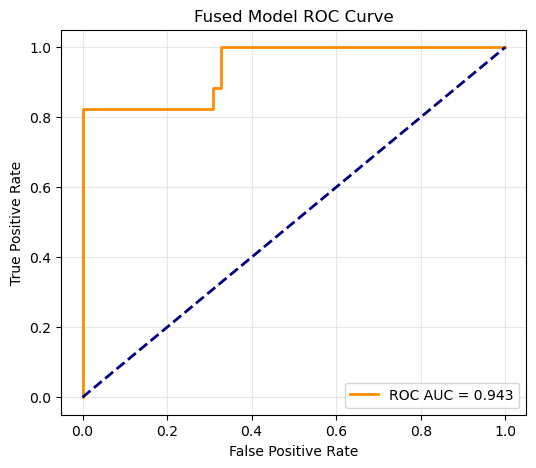

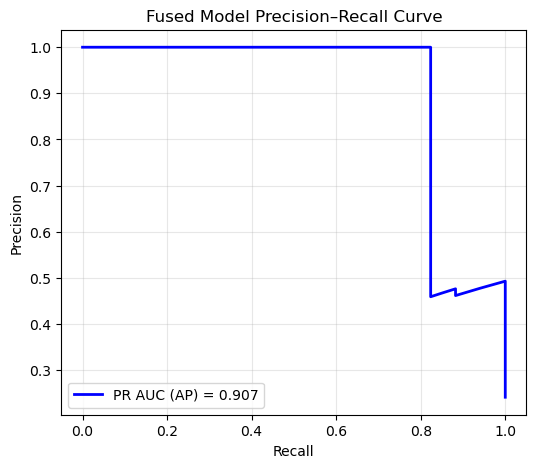

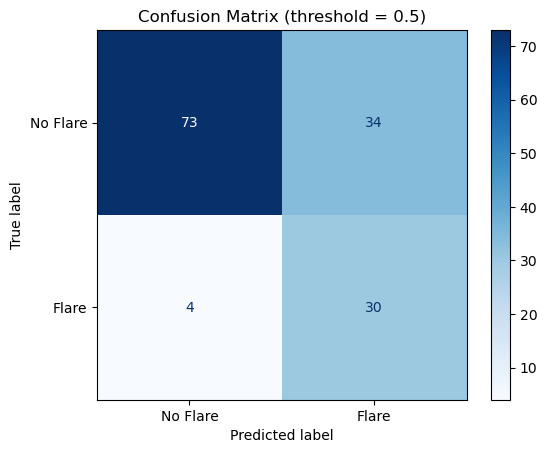

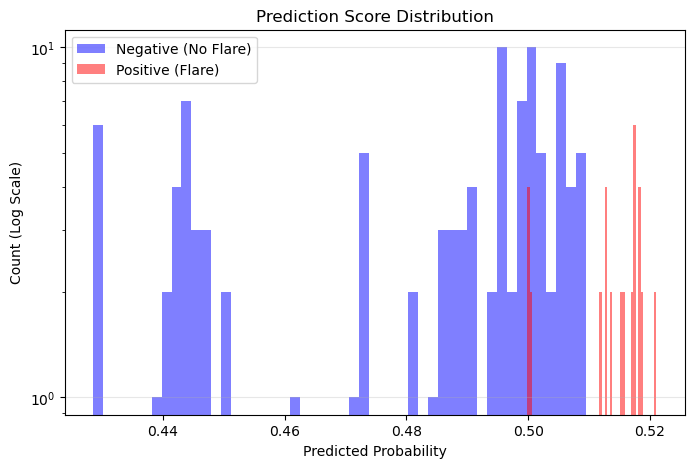


Final locked metrics:
→ ROC AUC: 0.9434
→ PR AUC:  0.9072


In [35]:


import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)


device = torch.device("cpu")

# 1. Load the full checkpoint dictionary
checkpoint_path = r"C:\Users\Owner\Onedrive\Desktop\solar_proj\models\fused_best.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# 2. Extract the weights (handling the nested "model_state_dict" key)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    print("Detected nested state_dict. Loading weights from 'model_state_dict'...")
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    print("Loading state_dict directly...")
    model.load_state_dict(checkpoint)

model.eval()

y_true = []
y_score = []

with torch.no_grad():
    for batch in val_loader:
        x_seq, x_img, y = batch
        x_seq = x_seq.to(device)
        x_img = x_img.to(device)

        logits = model(x_seq, x_img)
        probs = torch.sigmoid(logits).cpu().numpy()

        y_score.extend(probs)
        y_true.extend(y.numpy())

y_true = np.array(y_true)
y_score = np.array(y_score)


fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fused Model ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


precision, recall, _ = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', lw=2, label=f"PR AUC (AP) = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Fused Model Precision–Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()


threshold = 0.5
y_pred = (y_score >= threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Flare", "Flare"])
disp.plot(cmap="Blues", values_format='d')
plt.title(f"Confusion Matrix (threshold = {threshold})")
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(y_score[y_true == 0], bins=50, alpha=0.5, label="Negative (No Flare)", color='blue')
plt.hist(y_score[y_true == 1], bins=50, alpha=0.5, label="Positive (Flare)", color='red')
plt.yscale('log') # Use log scale if classes are imbalanced
plt.xlabel("Predicted Probability")
plt.ylabel("Count (Log Scale)")
plt.title("Prediction Score Distribution")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"\nFinal locked metrics:")
print(f"→ ROC AUC: {roc_auc:.4f}")
print(f"→ PR AUC:  {pr_auc:.4f}")

In [50]:

import os, math, time, types
from pathlib import Path
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
MODELS_DIR = ROOT / "models"
CNN_ARR_DIR = ROOT / "data" / "cnn_arrays"

# Files
LSTM_X = MODELS_DIR / "modelB_X.npy"
LSTM_Y = MODELS_DIR / "modelB_y.npy"
LSTM_WEIGHTS = MODELS_DIR / "lstm_modelB_best_state_dict.pth"
OUT_P_LSTM = MODELS_DIR / "P_LSTM.npy"

CNN_IMAGES = CNN_ARR_DIR / "cnn_images.npy"
CNN_INDEX  = CNN_ARR_DIR / "cnn_index.npy"
CNN_PICKLE_CANDIDATES = [
    MODELS_DIR / "solar_cnn_model_full.pth",
    MODELS_DIR / "solar_cnn_full.pth",
    MODELS_DIR / "solar_cnn_model.pth",
    MODELS_DIR / "solar_cnn_checkpoint.pth",
    MODELS_DIR / "solar_cnn_best_auc_cpu.pth",
    MODELS_DIR / "solar_cnn_best_auc_cpu_grouped.pth",
]
OUT_P_CNN = MODELS_DIR / "P_CNN.npy"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

class LSTMFlare(nn.Module):
    def __init__(self, n_features, hidden=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden,
                            num_layers=n_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))
    def forward(self, x):
        out,_ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last).squeeze(1)

if LSTM_X.exists() and LSTM_Y.exists():
    X = np.load(LSTM_X, allow_pickle=False)
    print("Loaded LSTM X:", X.shape)
    if np.isnan(X).any() or np.isinf(X).any():
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    lstm = LSTMFlare(X.shape[2]).to(device)
    if LSTM_WEIGHTS.exists():
        st = torch.load(LSTM_WEIGHTS, map_location=device)
        sd = st.get("model_state_dict", st.get("state_dict", st)) if isinstance(st, dict) else st
        lstm.load_state_dict(sd, strict=False)
    lstm.eval()

    ds = TensorDataset(torch.from_numpy(X.astype(np.float32)))
    loader = DataLoader(ds, batch_size=1024, shuffle=False)
    p_lstm = []
    with torch.no_grad():
        for (xb,) in loader:
            out = lstm(xb.to(device)).detach().cpu()
            p_lstm.append(torch.sigmoid(out).numpy())
    p_lstm = np.concatenate(p_lstm, axis=0)
    np.save(OUT_P_LSTM, p_lstm)
    print("Saved P_LSTM. Mean:", float(p_lstm.mean()))

class SolarCNNFlexible(nn.Module):
    def __init__(self, image_size):
        super().__init__()
        self.image_size = image_size
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        flat = 256 * (image_size // 16) * (image_size // 16)
        self.fc = nn.Sequential(nn.Linear(flat, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128,1))
    
    def forward(self, x):
        x = self.conv(x)
        # FIX: use .reshape instead of .view to handle non-contiguous memory
        x = x.reshape(x.size(0), -1) 
        return self.fc(x)


cnn_images = np.load(CNN_IMAGES, allow_pickle=True).astype(np.float32)
cnn_model = None
picked_path = None
for p in CNN_PICKLE_CANDIDATES:
    if p.exists():
        picked_path = p; break

if picked_path:
    try:
        print("Loading pickled CNN:", picked_path)
        cnn_model = torch.load(picked_path, map_location=device, weights_only=False)

        if isinstance(cnn_model, dict):
            state_dict = cnn_model.get("model_state_dict", cnn_model)
            cnn_model = None 
    except Exception as e:
        print("Pickle load failed, falling back to reconstruction.")

if cnn_model is None:

    candidate = next(MODELS_DIR.glob("*cnn*.pth"), None)
    chk = torch.load(candidate, map_location=device)
    state_dict = chk.get("model_state_dict", chk.get("state_dict", chk))
    
    # Infer size
    fc_key = next((k for k in state_dict.keys() if "fc.0.weight" in k or "fc.weight" in k), None)
    n_flat = state_dict[fc_key].shape[1]
    inferred_sz = int(round(math.sqrt(n_flat / 256.0) * 16.0))
    cnn_model = SolarCNNFlexible(inferred_sz).to(device)
    cnn_model.load_state_dict(state_dict, strict=False)
else:

    def patched_forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)
    cnn_model.forward = types.MethodType(patched_forward, cnn_model)
    cnn_model = cnn_model.to(device)

cnn_model.eval()


def make_cnn_batch_from_index(idxs, target_size):
    arr = []
    for i in idxs:
        img = cnn_images[int(i)]
        if img.ndim == 3 and img.shape[-1] == 3:
            img = np.transpose(img, (2,0,1))
        arr.append(img)
    tb = torch.from_numpy(np.stack(arr)).to(device)
    if tb.shape[-1] != target_size:
        tb = F.interpolate(tb, size=(target_size,target_size), mode="bilinear", align_corners=False)

    return tb.contiguous()

# Detection of working size
sample_img = torch.from_numpy(np.transpose(cnn_images[0], (2,0,1))).unsqueeze(0).to(device)
cnn_image_size = 256 
try:
    _ = cnn_model(sample_img)
    cnn_image_size = sample_img.shape[-1]
except:

    test_256 = F.interpolate(sample_img, size=(256, 256)).contiguous()
    _ = cnn_model(test_256)
    cnn_image_size = 256

print(f"CNN using image size: {cnn_image_size}")

batch_size = 32
p_cnn = []
with torch.no_grad():
    for i in range(0, len(cnn_images), batch_size):
        idxs = list(range(i, min(i+batch_size, len(cnn_images))))
        tb = make_cnn_batch_from_index(idxs, cnn_image_size)
        logits = cnn_model(tb)
        p_cnn.append(torch.sigmoid(logits).cpu().numpy().ravel())

p_cnn = np.concatenate(p_cnn, axis=0)
np.save(OUT_P_CNN, p_cnn)
print("Saved P_CNN. Mean:", float(p_cnn.mean()))
print("Inference Complete.")

DEVICE: cpu
Loaded LSTM X: (91821, 120, 9)
Saved P_LSTM. Mean: 0.6283001899719238
Loading pickled CNN: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\solar_cnn_model_full.pth
CNN using image size: 256
Saved P_CNN. Mean: 0.38101696968078613
Inference Complete.


In [51]:

import torch, numpy as np, math
from pathlib import Path
import torch.nn as nn
import torch.nn.functional as F

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
MODELS_DIR = ROOT / "models"
CNN_ARR_DIR = ROOT / "data" / "cnn_arrays"

CNN_IMAGES = CNN_ARR_DIR / "cnn_images.npy"
CNN_INDEX  = CNN_ARR_DIR / "cnn_index.npy"
PICKLE_CANDIDATES = [
    MODELS_DIR / "solar_cnn_model_full.pth",
    MODELS_DIR / "solar_cnn_full.pth",
    MODELS_DIR / "solar_cnn_model.pth",
    MODELS_DIR / "solar_cnn_checkpoint.pth",
    MODELS_DIR / "solar_cnn_best_auc_cpu_grouped.pth",
    MODELS_DIR / "solar_cnn_checkpoint.pth",
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

# load arrays
assert CNN_IMAGES.exists() and CNN_INDEX.exists(), f"Missing CNN arrays at {CNN_IMAGES} or {CNN_INDEX}"
cnn_images = np.load(CNN_IMAGES, allow_pickle=True)
cnn_index = np.load(CNN_INDEX, allow_pickle=True)
print("cnn_images shape:", cnn_images.shape, "cnn_index shape:", cnn_index.shape)

# Attempt to load a pickled model (safe)
cnn_model = None
picked_path = None
for p in PICKLE_CANDIDATES:
    if p.exists():
        picked_path = p
        break

if picked_path is None:
    print("No pickled CNN candidate found in", MODELS_DIR)
else:
    print("Trying to load pickled CNN from:", picked_path)
    try:

        cnn_model = torch.load(picked_path, map_location=device, weights_only=False)
        if isinstance(cnn_model, dict) and "model_state_dict" in cnn_model:
            print("Loaded a checkpoint dict (not a module). Will examine state_dict below instead.")
            state_dict = cnn_model["model_state_dict"]
            cnn_model = None
        elif isinstance(cnn_model, nn.Module):
            print("Loaded pickled module instance:", type(cnn_model).__name__)
            state_dict = cnn_model.state_dict()
        else:
            print("Pickle returned unexpected type:", type(cnn_model))
            state_dict = None
    except Exception as e:
        print("Pickle-load failed:", type(e).__name__, str(e))
        cnn_model = None
        state_dict = None

# If no pickled module, try to find checkpoint / state_dict
if cnn_model is None and state_dict is None:
    # try to locate any cnn .pth in models/
    candidate = None
    for c in MODELS_DIR.glob("*.pth"):
        if "cnn" in c.name.lower():
            candidate = c
            break
    if candidate is not None:
        print("Attempting to load checkpoint from:", candidate)
        try:
            chk = torch.load(candidate, map_location=device)
            if isinstance(chk, dict) and "model_state_dict" in chk:
                state_dict = chk["model_state_dict"]
                print("Found state_dict inside checkpoint.")
            elif isinstance(chk, dict) and all(isinstance(v, torch.Tensor) for v in chk.values()):
                state_dict = chk
                print("Loaded top-level state_dict.")
            else:
                # attempt some common keys
                for k in ("state_dict","model_state_dict","model"):
                    if isinstance(chk, dict) and k in chk:
                        state_dict = chk[k]; print("Recovered state_dict under key",k); break
                if state_dict is None:
                    print("Could not find usable state_dict in", candidate)
        except Exception as e:
            print("Loading candidate failed:", type(e).__name__, str(e))

# Print state_dict summary if available
if state_dict is not None:
    print("\nState_dict top keys (sample 30):")
    keys = list(state_dict.keys())
    for k in keys[:30]:
        v = state_dict[k]
        try:
            print(f"  {k} -> {tuple(v.shape)}")
        except Exception:
            print(f"  {k} -> (shape unknown)")
    print("... total keys:", len(keys))

if cnn_model is not None:
    print("\nModule attributes:", [n for n,_ in cnn_model.named_children()])
    has_conv = hasattr(cnn_model, "conv")
    has_fc   = hasattr(cnn_model, "fc")
    print("has conv:", has_conv, "has fc:", has_fc)
else:
    print("\nNo pickled module instance loaded. Diagnostics will use state_dict shapes where possible.")


sample_img = cnn_images[0]

if sample_img.ndim == 3 and sample_img.shape[-1] == 3:
    sample_t = torch.from_numpy(sample_img.transpose(2,0,1)[None]).float().to(device)
else:

    sample_t = torch.from_numpy(np.expand_dims(sample_img, 0)).float().to(device)

print("\nPrepared sample tensor shape:", tuple(sample_t.shape))


conv_out_shape = None
conv_flat_size = None
fc_in_features = None
try:
    if cnn_model is not None and hasattr(cnn_model, "conv"):
        with torch.no_grad():
            conv_out = cnn_model.conv(sample_t)
            conv_out_shape = tuple(conv_out.shape)
            conv_flat_size = int(conv_out.reshape(conv_out.size(0), -1).shape[1])
        print("conv_out shape (via cnn_model.conv):", conv_out_shape)
    else:

        if state_dict is not None:
            conv_keys = [k for k in state_dict.keys() if k.endswith(".weight") and state_dict[k].ndim==4]
            print("Detected conv weight keys (sample 10):", conv_keys[:10])

except Exception as e:
    print("Safe conv pass failed:", type(e).__name__, str(e))

try:
    if cnn_model is not None and hasattr(cnn_model, "fc"):
        # assume fc is Sequential and first linear is fc[0]
        if isinstance(cnn_model.fc, nn.Sequential):
            first_linear = next((m for m in cnn_model.fc if isinstance(m, nn.Linear)), None)
            if first_linear is not None:
                fc_in_features = first_linear.in_features
                fc_out_features = first_linear.out_features
                print("Found module fc first Linear in_features:", fc_in_features, "out_features:", fc_out_features)
        else:
            print("cnn_model.fc exists but is not Sequential. type:", type(cnn_model.fc))
    elif state_dict is not None:
        # find a 2D weight that plausibly is fc first weight: choose one with large second dimension
        cand = [(k, state_dict[k].shape) for k in state_dict if getattr(state_dict[k], "ndim",0)==2]
        cand_sorted = sorted(cand, key=lambda kv: kv[1][1], reverse=True)
        if len(cand_sorted)>0:
            print("Top candidate linear keys (name,shape):", cand_sorted[:5])
            fc_key, fc_shape = cand_sorted[0]
            fc_in_features = fc_shape[1]
            print("Using fc_key:", fc_key, "fc_in:", fc_in_features)
except Exception as e:
    print("FC inspection failed:", type(e).__name__, str(e))

print("\nSummary:")
print(" conv_flat_size:", conv_flat_size)
print(" fc_in_features:", fc_in_features)
print(" conv_out_shape (if computed):", conv_out_shape)
print("\nIf conv_flat_size != fc_in_features, that's the mismatch causing the view/matmul issues. Next step: can wrap the model with a tiny adapter (linear) to map conv_flat -> fc_in and run inference. Run the 'fix & inference' cell next.")


DEVICE: cpu
cnn_images shape: (4737, 128, 128, 3) cnn_index shape: (4737, 2)
Trying to load pickled CNN from: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\solar_cnn_model_full.pth
Loaded pickled module instance: SolarCNN

State_dict top keys (sample 30):
  conv.0.weight -> (32, 3, 3, 3)
  conv.0.bias -> (32,)
  conv.3.weight -> (64, 32, 3, 3)
  conv.3.bias -> (64,)
  conv.6.weight -> (128, 64, 3, 3)
  conv.6.bias -> (128,)
  conv.9.weight -> (256, 128, 3, 3)
  conv.9.bias -> (256,)
  fc.0.weight -> (128, 65536)
  fc.0.bias -> (128,)
  fc.3.weight -> (1, 128)
  fc.3.bias -> (1,)
... total keys: 12

Module attributes: ['conv', 'fc']
has conv: True has fc: True

Prepared sample tensor shape: (1, 3, 128, 128)
conv_out shape (via cnn_model.conv): (1, 256, 8, 8)
Found module fc first Linear in_features: 65536 out_features: 128

Summary:
 conv_flat_size: 16384
 fc_in_features: 65536
 conv_out_shape (if computed): (1, 256, 8, 8)

If conv_flat_size != fc_in_features, that's the mismatch ca

Shapes -> P_LSTM: (91821,) P_CNN: (4737,) matched: (646, 2) y_all: (91821,)
Paired dataset size: (646, 2) Label counts: [553  93]
Train pairs: 484 Val pairs: 162
Saved ensemble model and metadata.


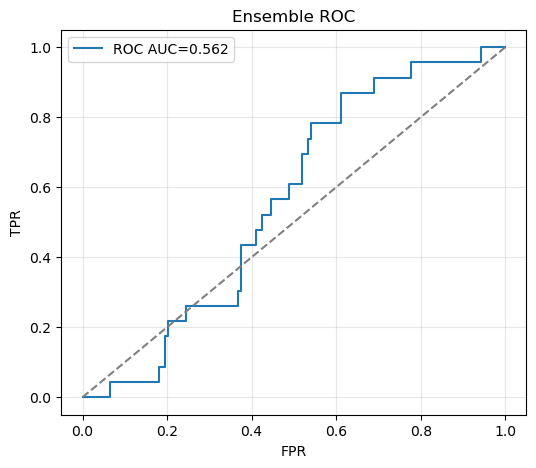

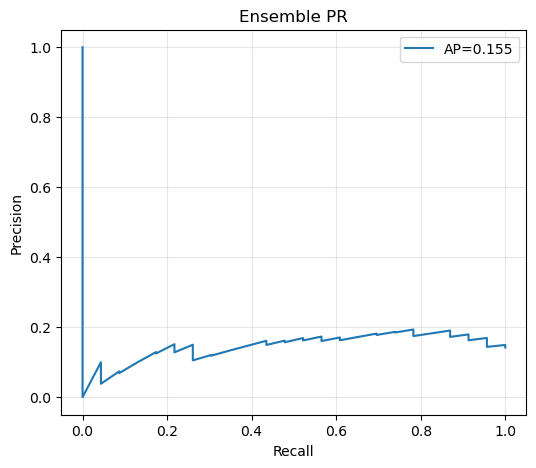

Val AUC: 0.5618, AP: 0.1552
Best TSS: 0.1711 at thr 0.470 -> TP,FP,FN,TN = (18, 85, 5, 54)
Confusion (TP,FP,FN,TN): (np.int64(18), np.int64(85), np.int64(5), np.int64(54))
POD (recall): 0.782608695652174
FAR: 0.6115107913669064


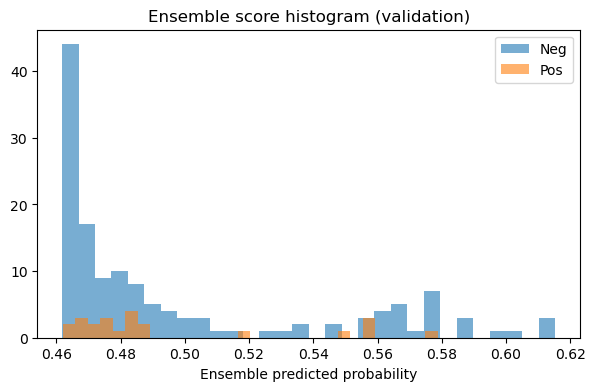

Logistic coefficients (LSTM_prob, CNN_prob): [-0.06693033  0.62962755] intercept: -0.1112302299196652

Production recommendation:
 - Use ensemble logistic model for samples with both LSTM+CNN present (only applicable to matched pairs).
 - For sequences that have no CNN match, fallback to LSTM alone (use P_LSTM.npy probability).
 - For images without seq, fallback to CNN alone (use P_CNN.npy).


In [52]:

import numpy as np, json, joblib, os
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
MODELS = ROOT / "models"


P_LSTM_F = MODELS / "P_LSTM.npy"
P_CNN_F  = MODELS / "P_CNN.npy"
MATCHED_F = MODELS / "matched_seq_to_cnn_pairs.npy"
Y_F = MODELS / "modelB_y.npy"

# sanity
for p in (P_LSTM_F, P_CNN_F, MATCHED_F, Y_F):
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")

p_lstm = np.load(P_LSTM_F, allow_pickle=False)  # shape (n_seq,)
p_cnn  = np.load(P_CNN_F, allow_pickle=False)   # shape (n_img,)
matched = np.load(MATCHED_F, allow_pickle=True).astype(int)  # shape (Npairs,2)
y_all = np.load(Y_F, allow_pickle=False)

print("Shapes -> P_LSTM:", p_lstm.shape, "P_CNN:", p_cnn.shape, "matched:", matched.shape, "y_all:", y_all.shape)

# Build dataset on matched pairs
seq_idxs = matched[:,0]
cnn_idxs = matched[:,1]

# Filter out any -1 (unmatched) pairs just in case
keep = (cnn_idxs >= 0) & (seq_idxs >= 0)
seq_idxs = seq_idxs[keep]; cnn_idxs = cnn_idxs[keep]

X_pairs = np.column_stack([p_lstm[seq_idxs], p_cnn[cnn_idxs]])
y_pairs = y_all[seq_idxs].astype(int)

print("Paired dataset size:", X_pairs.shape, "Label counts:", np.bincount(y_pairs))

# Split (stratified)
X_tr, X_val, y_tr, y_val, idx_tr, idx_val = train_test_split(
    X_pairs, y_pairs, np.arange(len(y_pairs)), test_size=0.25, random_state=42, stratify=y_pairs
)

print("Train pairs:", X_tr.shape[0], "Val pairs:", X_val.shape[0])

# Train logistic regression on probs (no scaling required since inputs are probs)
clf = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000)
clf.fit(X_tr, y_tr)

# Save ensemble
os.makedirs(MODELS, exist_ok=True)
joblib.dump(clf, MODELS / "ensemble_logreg.pkl")
meta = {
    "method": "logistic_regression",
    "trained_on_pairs": int(len(X_tr)),
    "val_pairs": int(len(X_val)),
    "coefficients": clf.coef_.tolist(),
    "intercept": float(clf.intercept_[0]),
}
with open(MODELS / "ensemble_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved ensemble model and metadata.")

# Evaluate on validation set
probs_val = clf.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, probs_val)
ap  = average_precision_score(y_val, probs_val)

# ROC + PR
fpr, tpr, _ = roc_curve(y_val, probs_val)
prec, rec, _ = precision_recall_curve(y_val, probs_val)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr, label=f"ROC AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray'); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Ensemble ROC"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"AP={ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Ensemble PR"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# TSS sweep, pick best threshold
ths = np.linspace(0.01, 0.99, 99)
best_tss = -99; best_thr = None; best_cm = None
for thr in ths:
    preds = (probs_val >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    pd_rate = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fa_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tss = pd_rate - fa_rate
    if tss > best_tss:
        best_tss = tss; best_thr = thr; best_cm = (int(tp), int(fp), int(fn), int(tn))

print(f"Val AUC: {auc:.4f}, AP: {ap:.4f}")
print(f"Best TSS: {best_tss:.4f} at thr {best_thr:.3f} -> TP,FP,FN,TN = {best_cm}")

# Confusion matrix at best threshold
best_preds = (probs_val >= best_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, best_preds).ravel()
print("Confusion (TP,FP,FN,TN):", (tp,fp,fn,tn))
print("POD (recall):", tp/(tp+fn) if (tp+fn)>0 else None)
print("FAR:", fp/(fp+tn) if (fp+tn)>0 else None)

# Score distributions
plt.figure(figsize=(7,4))
plt.hist(probs_val[y_val==0], bins=30, alpha=0.6, label="Neg", density=False)
plt.hist(probs_val[y_val==1], bins=30, alpha=0.6, label="Pos", density=False)
plt.xlabel("Ensemble predicted probability")
plt.legend(); plt.title("Ensemble score histogram (validation)"); plt.show()

print("Logistic coefficients (LSTM_prob, CNN_prob):", clf.coef_[0], "intercept:", clf.intercept_[0])


print("\nProduction recommendation:")
print(f" - Use ensemble logistic model for samples with both LSTM+CNN present (only applicable to matched pairs).")
print(f" - For sequences that have no CNN match, fallback to LSTM alone (use P_LSTM.npy probability).")
print(f" - For images without seq, fallback to CNN alone (use P_CNN.npy).")



SUMMARY METRICS
LSTM   -> samples: 91821, ROC AUC: 0.4957, AP: 0.1268
CNN    -> samples: 4737, ROC AUC: 0.8032, AP: 0.5579
ENSEMBLE -> paired samples: 646, ROC AUC: 0.5836, AP: 0.1637

LSTM best TSS 0.0001 at thr 0.080 -> TP,FP,FN,TN: (11720, 80094, 0, 7)
CNN  best TSS 0.5010 at thr 0.810 -> TP,FP,FN,TN: (444, 542, 255, 3496)
ENS  best TSS 0.1970 at thr 0.470 -> TP,FP,FN,TN: (75, 337, 18, 216)


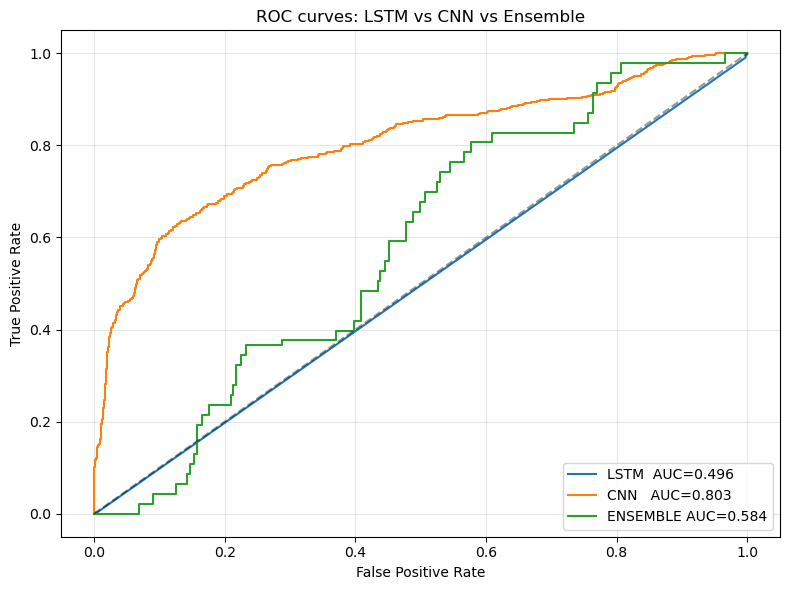

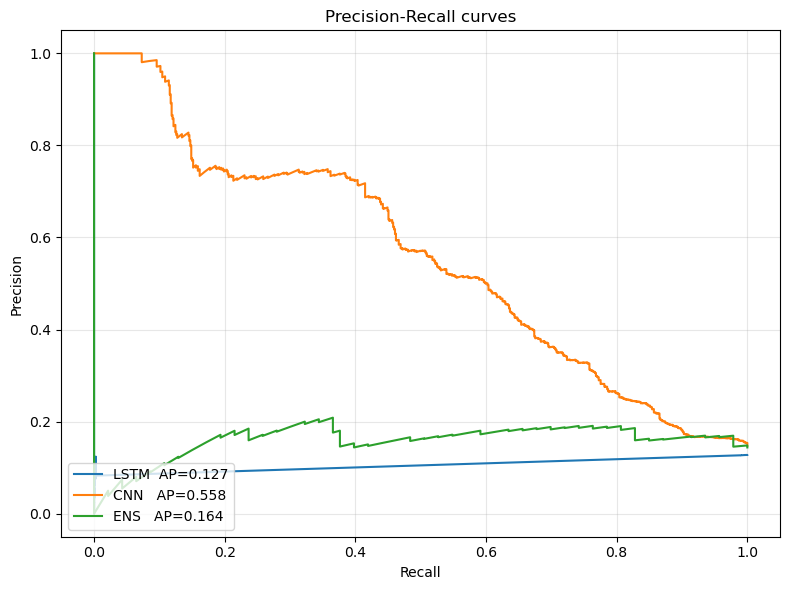


ACCURACY @ best-TSS thresholds:
LSTM  acc=0.128 (total=91821)   thr=0.080
CNN   acc=0.832 (total=4737)   thr=0.810
ENS   acc=0.450 (total=646)   thr=0.470

Saved plots to models/ and numeric summary to models/roc_pr_summary.json


In [53]:

import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix
)
import math
from scipy.special import expit as sigmoid

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
MODELS = ROOT / "models"
DATA = ROOT / "data"

P_LSTM_PATH = MODELS / "P_LSTM.npy"
P_CNN_PATH  = MODELS / "P_CNN.npy"
LSTM_Y_PATH = MODELS / "modelB_y.npy"              # ground truth for LSTM sequences
CNN_CSV     = ROOT / "final_cnn_dataset.csv"      # labels for CNN images
MATCHED     = MODELS / "matched_seq_to_cnn_pairs.npy"  # pairs (seq_idx, cnn_idx)


ENSEMBLE_COEF = np.array([-0.06693033, 0.62962755])   # [w_lstm, w_cnn]
ENSEMBLE_INTERCEPT = -0.1112302299196652


assert P_LSTM_PATH.exists(), f"Missing {P_LSTM_PATH}"
assert P_CNN_PATH.exists(),  f"Missing {P_CNN_PATH}"
P_LSTM = np.load(P_LSTM_PATH)
P_CNN  = np.load(P_CNN_PATH)

y_lstm = np.load(LSTM_Y_PATH)   # same length as P_LSTM

# CNN ground-truth from CSV (should be same order as cnn_images / cnn_index)
if CNN_CSV.exists():
    df_cnn = pd.read_csv(CNN_CSV)
    if "label_MX_24h" not in df_cnn.columns:
        raise RuntimeError("final_cnn_dataset.csv missing 'label_MX_24h' column")
    y_cnn = df_cnn["label_MX_24h"].astype(int).values
else:
    raise FileNotFoundError(f"Missing CNN CSV at {CNN_CSV}")

# matched indices for ensemble evaluation
matched_pairs = np.load(MATCHED, allow_pickle=True)
matched_pairs = np.asarray(matched_pairs, dtype=int)
# remove any -1 rows (if any)
matched_pairs = matched_pairs[matched_pairs[:,1] != -1]

# build paired arrays (only where both preds exist)
seq_idx = matched_pairs[:,0]
cnn_idx = matched_pairs[:,1]

p_lstm_matched = P_LSTM[seq_idx]
p_cnn_matched  = P_CNN[cnn_idx]
y_matched      = y_lstm[seq_idx]   


def ensemble_prob(pl, pc, coef=ENSEMBLE_COEF, intercept=ENSEMBLE_INTERCEPT):
    lin = intercept + coef[0]*pl + coef[1]*pc
    return sigmoid(lin)

P_ENSEMBLE = ensemble_prob(p_lstm_matched, p_cnn_matched)


def best_tss_and_confusion(y_true, probs, thr_grid=np.linspace(0.01,0.99,99)):
    best_tss = -999
    best_thr = None
    best_cm = None
    for thr in thr_grid:
        preds = (probs >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        pd_rate = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fa_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        tss = pd_rate - fa_rate
        if tss > best_tss:
            best_tss = tss
            best_thr = thr
            best_cm = (int(tp), int(fp), int(fn), int(tn))
    return best_tss, best_thr, best_cm


fpr_l, tpr_l, _ = roc_curve(y_lstm, P_LSTM)
auc_l = auc(fpr_l, tpr_l)
prec_l, rec_l, _ = precision_recall_curve(y_lstm, P_LSTM)
ap_l = auc(rec_l, prec_l)  # equivalent to average_precision_score
ap_l2 = average_precision_score(y_lstm, P_LSTM)

fpr_c, tpr_c, _ = roc_curve(y_cnn, P_CNN)
auc_c = auc(fpr_c, tpr_c)
prec_c, rec_c, _ = precision_recall_curve(y_cnn, P_CNN)
ap_c = auc(rec_c, prec_c)
ap_c2 = average_precision_score(y_cnn, P_CNN)

fpr_e, tpr_e, _ = roc_curve(y_matched, P_ENSEMBLE)
auc_e = auc(fpr_e, tpr_e)
prec_e, rec_e, _ = precision_recall_curve(y_matched, P_ENSEMBLE)
ap_e2 = average_precision_score(y_matched, P_ENSEMBLE)

# best TSSs
tss_l, thr_l, cm_l = best_tss_and_confusion(y_lstm, P_LSTM)
tss_c, thr_c, cm_c = best_tss_and_confusion(y_cnn, P_CNN)
tss_e, thr_e, cm_e = best_tss_and_confusion(y_matched, P_ENSEMBLE)


print("\nSUMMARY METRICS")
print(f"LSTM   -> samples: {len(P_LSTM)}, ROC AUC: {auc_l:.4f}, AP: {ap_l2:.4f}")
print(f"CNN    -> samples: {len(P_CNN)}, ROC AUC: {auc_c:.4f}, AP: {ap_c2:.4f}")
print(f"ENSEMBLE -> paired samples: {len(P_ENSEMBLE)}, ROC AUC: {auc_e:.4f}, AP: {ap_e2:.4f}")
print()
print("LSTM best TSS {:.4f} at thr {:.3f} -> TP,FP,FN,TN: {}".format(tss_l, thr_l, cm_l))
print("CNN  best TSS {:.4f} at thr {:.3f} -> TP,FP,FN,TN: {}".format(tss_c, thr_c, cm_c))
print("ENS  best TSS {:.4f} at thr {:.3f} -> TP,FP,FN,TN: {}".format(tss_e, thr_e, cm_e))


plt.figure(figsize=(8,6))
plt.plot(fpr_l, tpr_l, label=f"LSTM  AUC={auc_l:.3f}")
plt.plot(fpr_c, tpr_c, label=f"CNN   AUC={auc_c:.3f}")
plt.plot(fpr_e, tpr_e, label=f"ENSEMBLE AUC={auc_e:.3f}")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves: LSTM vs CNN vs Ensemble")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS / "roc_lstm_cnn_ensemble.png", dpi=150)
plt.show()


plt.figure(figsize=(8,6))
plt.plot(rec_l, prec_l, label=f"LSTM  AP={ap_l2:.3f}")
plt.plot(rec_c, prec_c, label=f"CNN   AP={ap_c2:.3f}")
plt.plot(rec_e, prec_e, label=f"ENS   AP={ap_e2:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall curves")
plt.legend(loc="lower left"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS / "pr_lstm_cnn_ensemble.png", dpi=150)
plt.show()


def acc_at_cm(cm):
    tp, fp, fn, tn = cm
    total = tp+fp+fn+tn
    acc = (tp+tn)/total if total>0 else None
    return acc, total

acc_l, tot_l = acc_at_cm(cm_l)
acc_c, tot_c = acc_at_cm(cm_c)
acc_e, tot_e = acc_at_cm(cm_e)

print("\nACCURACY @ best-TSS thresholds:")
print(f"LSTM  acc={acc_l:.3f} (total={tot_l})   thr={thr_l:.3f}")
print(f"CNN   acc={acc_c:.3f} (total={tot_c})   thr={thr_c:.3f}")
print(f"ENS   acc={acc_e:.3f} (total={tot_e})   thr={thr_e:.3f}")

# Save numeric summary
summary = {
    "LSTM": {"auc": float(auc_l), "ap": float(ap_l2), "best_tss": float(tss_l), "best_thr": float(thr_l), "cm": cm_l},
    "CNN":  {"auc": float(auc_c), "ap": float(ap_c2), "best_tss": float(tss_c), "best_thr": float(thr_c), "cm": cm_c},
    "ENS":  {"auc": float(auc_e), "ap": float(ap_e2), "best_tss": float(tss_e), "best_thr": float(thr_e), "cm": cm_e},
}
import json
with open(MODELS / "roc_pr_summary.json","w") as fh:
    json.dump(summary, fh, indent=2)

print("\nSaved plots to models/ and numeric summary to models/roc_pr_summary.json")


In [54]:
print(lstm_model)
print("Trainable params:", sum(p.numel() for p in lstm_model.parameters() if p.requires_grad))


LSTMFlare(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Trainable params: 211585


In [55]:
print("P_LSTM min:", P_LSTM.min())
print("P_LSTM max:", P_LSTM.max())
print("P_LSTM mean:", P_LSTM.mean())


P_LSTM min: 0.06082305
P_LSTM max: 0.76297224
P_LSTM mean: 0.6283002


In [4]:
import json

scaler_path = r"C:\Users\Owner\OneDrive\Desktop\solar_proj\models\lstm_scaler.json"

with open(scaler_path, 'r') as f:
    scaler_data = json.load(f)

print(scaler_data)

{'feat_mean': [5.551113819748783e+21, 1.5891011953353882, 35.160884857177734, 341.5296630859375, 6956799492096.0, 6956799492096.0], 'feat_std': [inf, 1.7384436130523682, 9.651586532592773, 534.302001953125, 10512640245760.0, 10512640245760.0], 'feature_cols': ['USFLUX', 'R_VALUE', 'MEANGAM', 'TOTUSJH', 'TOTUSJZ', 'TOTUSJZ']}


Found required files. Starting...
Loaded LSTM X shape: (91821, 120, 9)  y shape: (91821,)
No saved scaler found in candidates. Will standardize using trainless fallback (mean/std from X).


C:\Users\Owner\anaconda3\envs\solar_flare_one\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1872: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


Fallback scaler created from X stats.
Found NaN/Inf in scaled X -> NaN:39498 Inf:0 -> replacing with 0.
Loaded LSTM weights from: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\lstm_modelB_best_state_dict.pth
Saved P_LSTM -> C:\Users\Owner\Onedrive\Desktop\solar_proj\models\P_LSTM.npy shape: (91821,) mean: 0.2716860771179199

--- LSTM metrics (all sequences) ---
[LSTM(all)] ROC AUC: 0.9235  AP: 0.6838  Best TSS: 0.6999 @thr 0.380 cm=(10707, 17111, 1013, 62990)
Loaded P_CNN: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\P_CNN.npy shape: (4737,) mean: 0.38101696968078613
Recovered CNN labels directly from final_cnn_dataset.csv
Matched pairs loaded: (646, 2)
Trained ensemble logistic regression, saved -> C:\Users\Owner\Onedrive\Desktop\solar_proj\models\ensemble_logreg.pkl
[ENSEMBLE(val)] ROC AUC: 0.9296  AP: 0.7065  Best TSS: 0.7410 @thr 0.090 cm=(23, 36, 0, 103)
[CNN(full)] ROC AUC: 0.8032  AP: 0.5579  Best TSS: 0.5010 @thr 0.810 cm=(444, 542, 255, 3496)


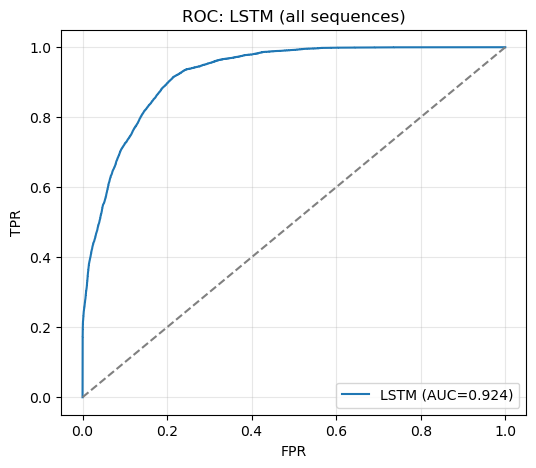

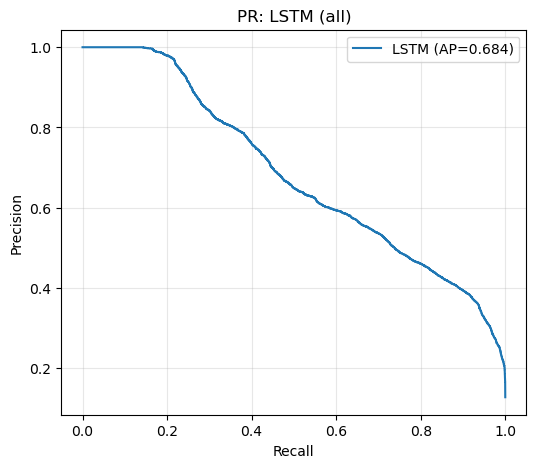

[CNN(full)] ROC AUC: 0.8032  AP: 0.5579  Best TSS: 0.5010 @thr 0.810 cm=(444, 542, 255, 3496)


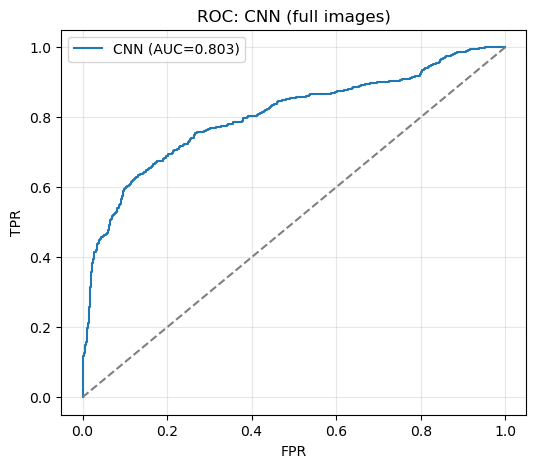

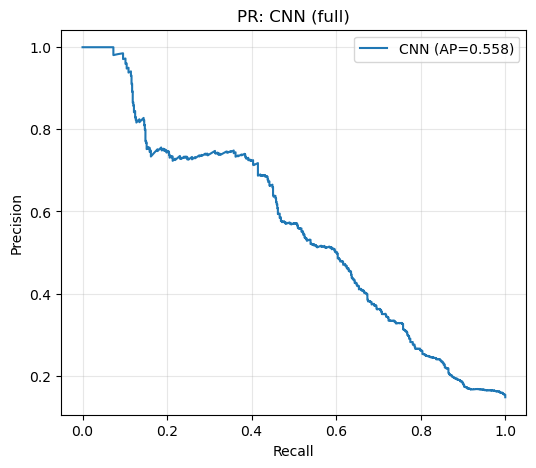

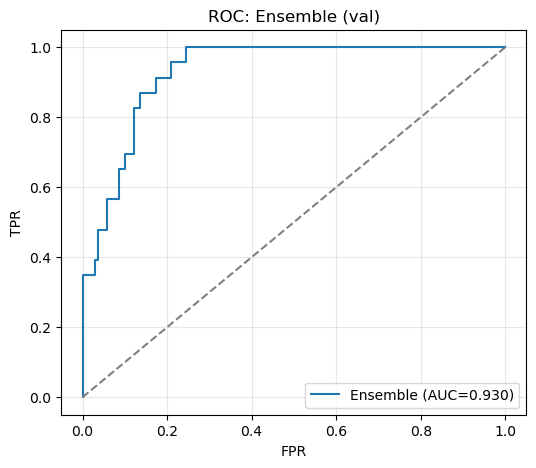

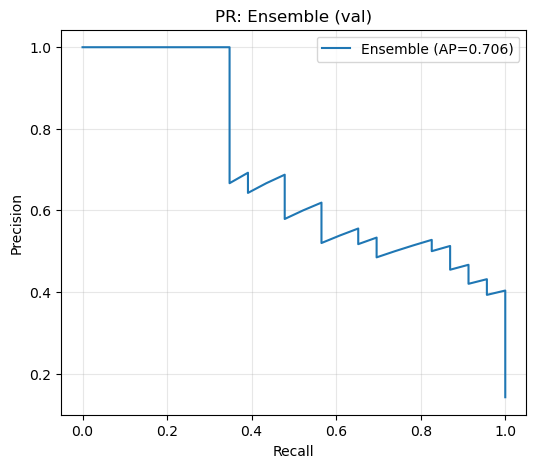


Saved ROC/PR summary to: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\roc_pr_summary.json

Done. Plots saved to: C:\Users\Owner\Onedrive\Desktop\solar_proj\models


In [1]:

import os, math, json, time
from pathlib import Path
import numpy as np
import joblib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
MODELS = ROOT / "models"
DATA = ROOT / "data"


X_PATH = MODELS / "modelB_X.npy"
Y_PATH = MODELS / "modelB_y.npy"
MATCHED_PATH = MODELS / "matched_seq_to_cnn_pairs.npy"
P_CNN_PATH = MODELS / "P_CNN.npy"
P_LSTM_OUT = MODELS / "P_LSTM.npy"
ENSEMBLE_MODEL_PATH = MODELS / "ensemble_logreg.pkl"
ROC_SUM_PATH = MODELS / "roc_pr_summary.json"
PLOTS_DIR = MODELS
SCALER_CANDIDATES = [MODELS / "lstm_scaler", MODELS / "lstm_scaler.pkl", MODELS / "lstm_scaler.joblib"]
LSTM_WEIGHTS_CAND = [MODELS / "lstm_modelB_best_state_dict.pth", MODELS / "lstm_best_state_dict.pth", MODELS / "lstm_modelB_state_dict.pth"]


for p in [X_PATH, Y_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required file missing: {p}")

print("Found required files. Starting...")


class LSTMFlare(nn.Module):
    def __init__(self, n_features, hidden=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden,
                            num_layers=n_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last).squeeze(1)


X = np.load(X_PATH, allow_pickle=False)
y = np.load(Y_PATH, allow_pickle=False).astype(int)
print("Loaded LSTM X shape:", X.shape, " y shape:", y.shape)


scaler = None
for s in SCALER_CANDIDATES:
    if s.exists():
        try:
            scaler = joblib.load(s)
            print("Loaded scaler from:", s)
            break
        except Exception as e:
            print("Scaler load failed from", s, "->", type(e).__name__, e)
if scaler is None:
    print("No saved scaler found in candidates. Will standardize using trainless fallback (mean/std from X).")

    feat_mean = np.nanmean(X.reshape(-1, X.shape[-1]), axis=0)
    feat_std = np.nanstd(X.reshape(-1, X.shape[-1]), axis=0)
    feat_std[feat_std == 0] = 1.0
    class _FakeScaler:
        def __init__(self, mean, std): self.mean=mean; self.scale=std
        def transform(self, arr): return (arr - self.mean[None, None, :]) / self.scale[None, None, :]
    scaler = _FakeScaler(feat_mean, feat_std)
    print("Fallback scaler created from X stats.")


nsamples, seqlen, nfeat = X.shape
Xr = X.reshape(-1, nfeat)
Xr_scaled = scaler.transform(Xr) 
X_scaled = Xr_scaled.reshape(nsamples, seqlen, nfeat)

n_nan = np.isnan(X_scaled).sum()
n_inf = np.isinf(X_scaled).sum()
if n_nan or n_inf:
    print(f"Found NaN/Inf in scaled X -> NaN:{n_nan} Inf:{n_inf} -> replacing with 0.")
    X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm = LSTMFlare(n_features=nfeat).to(device)

loaded = False
for cand in LSTM_WEIGHTS_CAND:
    if cand.exists():
        try:
            st = torch.load(cand, map_location=device)

            sd = st.get("model_state_dict", st.get("state_dict", st)) if isinstance(st, dict) else st
            lstm.load_state_dict(sd, strict=False)
            print("Loaded LSTM weights from:", cand)
            loaded = True
            break
        except Exception as e:
            print("Failed loading LSTM from", cand, "->", type(e).__name__, e)
if not loaded:

    for p in MODELS.glob("*lstm*.pth"):
        try:
            st = torch.load(p, map_location=device)
            sd = st.get("model_state_dict", st.get("state_dict", st)) if isinstance(st, dict) else st
            lstm.load_state_dict(sd, strict=False)
            print("Loaded LSTM weights from fallback:", p)
            loaded = True
            break
        except Exception:
            pass
if not loaded:
    print("Warning: no LSTM weights loaded (continuing with random init).")

lstm.eval()

batch = 1024
pl = []
with torch.no_grad():
    for i in range(0, nsamples, batch):
        xb = torch.from_numpy(X_scaled[i:i+batch].astype(np.float32)).to(device)
        logits = lstm(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        pl.append(probs)
p_lstm = np.concatenate(pl, axis=0)
np.save(P_LSTM_OUT, p_lstm)
print("Saved P_LSTM ->", P_LSTM_OUT, "shape:", p_lstm.shape, "mean:", float(p_lstm.mean()))

def compute_metrics(y_true, probs, label="model"):
    out = {}
    out['roc_auc'] = float(roc_auc_score(y_true, probs)) if len(np.unique(y_true)) > 1 else float("nan")
    out['ap'] = float(average_precision_score(y_true, probs)) if len(np.unique(y_true)) > 1 else float("nan")
    # TSS sweep
    best_tss = -1; best_thr = None; best_cm=None
    for thr in np.linspace(0.01,0.99,99):
        preds = (probs >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        pd_rate = tp/(tp+fn) if (tp+fn)>0 else 0.0
        fa_rate = fp/(fp+tn) if (fp+tn)>0 else 0.0
        tss = pd_rate - fa_rate
        if tss > best_tss:
            best_tss = tss; best_thr=thr; best_cm=(int(tp), int(fp), int(fn), int(tn))
    out['best_tss'] = float(best_tss)
    out['best_thr'] = float(best_thr)
    out['best_cm'] = best_cm
    print(f"[{label}] ROC AUC: {out['roc_auc']:.4f}  AP: {out['ap']:.4f}  Best TSS: {out['best_tss']:.4f} @thr {out['best_thr']:.3f} cm={out['best_cm']}")
    return out

print("LSTM metrics (all sequences) ")
lstm_metrics = compute_metrics(y, p_lstm, label="LSTM(all)")


p_cnn = None
if P_CNN_PATH.exists():
    p_cnn = np.load(P_CNN_PATH, allow_pickle=True)
    print("Loaded P_CNN:", P_CNN_PATH, "shape:", p_cnn.shape, "mean:", float(p_cnn.mean()))
else:
    print("P_CNN.npy not found; ensemble will be impossible unless have P_CNN available.")


cnn_labels = None
cnn_csv = ROOT / "final_cnn_dataset.csv"
if p_cnn is not None and cnn_csv.exists():
    try:
        import pandas as pd
        df_cnn = pd.read_csv(cnn_csv)

        if len(df_cnn) == len(p_cnn) and "label_MX_24h" in df_cnn.columns:
            cnn_labels = df_cnn["label_MX_24h"].astype(int).values
            print("Recovered CNN labels directly from final_cnn_dataset.csv")
        else:
            print("final_cnn_dataset.csv exists but doesn't align shape -> skipping direct mapping; ensemble will use y from matched seqs instead.")
    except Exception as e:
        print("Failed to parse final_cnn_dataset.csv:", e)


if (MATCHED_PATH.exists() and p_cnn is not None):
    matched = np.load(MATCHED_PATH, allow_pickle=True)
    matched = np.asarray(matched, dtype=int)
    # keep only valid (cnn_idx != -1)
    valid_mask = matched[:,1] != -1
    matched = matched[valid_mask]
    print("Matched pairs loaded:", matched.shape)
else:
    matched = None
    print("No matched pairs or no P_CNN available -> cannot build paired ensemble dataset.")


ensemble_summary = {}
if matched is not None and len(matched)>0:
    seq_idx = matched[:,0].astype(int)
    cnn_idx = matched[:,1].astype(int)
    # corresponding probs
    p1 = p_lstm[seq_idx]
    p2 = p_cnn[cnn_idx]
    labels_pairs = y[seq_idx].astype(int)
    # split train/val stratified
    X_pairs = np.vstack([p1, p2]).T
    X_tr, X_val, y_tr, y_val, idx_tr, idx_val = train_test_split(X_pairs, labels_pairs, np.arange(len(labels_pairs)),
                                                                  test_size=0.25, random_state=42, stratify=labels_pairs)
    # train logistic regression
    clf = LogisticRegression(solver="liblinear")
    clf.fit(X_tr, y_tr)
    joblib.dump(clf, ENSEMBLE_MODEL_PATH)
    print("Trained ensemble logistic regression, saved ->", ENSEMBLE_MODEL_PATH)
    # predict on val
    val_probs = clf.predict_proba(X_val)[:,1]
    ensemble_metrics = compute_metrics(y_val, val_probs, label="ENSEMBLE(val)")
    # save summary
    ensemble_summary = {
        "coef": clf.coef_.tolist(), "intercept": float(clf.intercept_[0]),
        "n_pairs": int(len(labels_pairs)),
        "train_pairs": int(len(y_tr)), "val_pairs": int(len(y_val)),
        "ensemble_metrics": ensemble_metrics
    }
else:
    print("Skipping ensemble training (no matched pairs).")


cnn_metrics = {}
if p_cnn is not None and cnn_labels is not None:
    cnn_metrics = compute_metrics(cnn_labels, p_cnn, label="CNN(full)")
else:
    print("CNN(full) metrics skipped (no cnn_labels available).")


plt.rcParams.update({"figure.max_open_warning": 0})
fig_root = PLOTS_DIR
plots = []

# LSTM ROC + PR (all)
fpr, tpr, _ = roc_curve(y, p_lstm)
prec, rec, _ = precision_recall_curve(y, p_lstm)
plt.figure(figsize=(6,5)); plt.plot(fpr,tpr,label=f"LSTM (AUC={lstm_metrics['roc_auc']:.3f})"); plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC: LSTM (all sequences)"); plt.legend(); plt.grid(alpha=0.3)
p = fig_root / "roc_lstm_all.png"; plt.savefig(p); plt.show(); plots.append(str(p))
plt.figure(figsize=(6,5)); plt.plot(rec,prec,label=f"LSTM (AP={lstm_metrics['ap']:.3f})"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR: LSTM (all)"); plt.legend(); plt.grid(alpha=0.3)
p = fig_root / "pr_lstm_all.png"; plt.savefig(p); plt.show(); plots.append(str(p))


if p_cnn is not None and cnn_labels is not None:
    cm = compute_metrics(cnn_labels, p_cnn, label="CNN(full)")
    fpr, tpr, _ = roc_curve(cnn_labels, p_cnn)
    prec, rec, _ = precision_recall_curve(cnn_labels, p_cnn)
    plt.figure(figsize=(6,5)); plt.plot(fpr,tpr,label=f"CNN (AUC={cm['roc_auc']:.3f})"); plt.plot([0,1],[0,1],"--",color="gray")
    plt.title("ROC: CNN (full images)"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.grid(alpha=0.3)
    p = fig_root / "roc_cnn_full.png"; plt.savefig(p); plt.show(); plots.append(str(p))
    plt.figure(figsize=(6,5)); plt.plot(rec,prec,label=f"CNN (AP={cm['ap']:.3f})"); plt.title("PR: CNN (full)"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.grid(alpha=0.3)
    p = fig_root / "pr_cnn_full.png"; plt.savefig(p); plt.show(); plots.append(str(p))

if ensemble_summary:
    ytrue_val = y_val
    yscore_val = val_probs
    fpr, tpr, _ = roc_curve(ytrue_val, yscore_val)
    prec, rec, _ = precision_recall_curve(ytrue_val, yscore_val)
    plt.figure(figsize=(6,5)); plt.plot(fpr,tpr,label=f"Ensemble (AUC={ensemble_metrics['roc_auc']:.3f})"); plt.plot([0,1],[0,1],"--",color="gray")
    plt.title("ROC: Ensemble (val)") ; plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.grid(alpha=0.3)
    p = fig_root / "roc_ensemble_val.png"; plt.savefig(p); plt.show(); plots.append(str(p))
    plt.figure(figsize=(6,5)); plt.plot(rec,prec,label=f"Ensemble (AP={ensemble_metrics['ap']:.3f})"); plt.title("PR: Ensemble (val)"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.grid(alpha=0.3)
    p = fig_root / "pr_ensemble_val.png"; plt.savefig(p); plt.show(); plots.append(str(p))

summary = {
    "LSTM_all": lstm_metrics,
    "CNN_full": cnn_metrics if cnn_metrics else None,
    "ensemble": ensemble_summary if ensemble_summary else None,
    "files": {"p_lstm": str(P_LSTM_OUT), "p_cnn": str(P_CNN_PATH) if P_CNN_PATH.exists() else None, "plots": plots}
}
with open(ROC_SUM_PATH, "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved ROC/PR summary to:", ROC_SUM_PATH)

print("\nDone. Plots saved to:", PLOTS_DIR)


In [2]:

import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
X_path = ROOT / "models" / "modelB_X.npy"
assert X_path.exists(), X_path

X = np.load(X_path, allow_pickle=False)   # shape (N, 120, 9)
print("X shape:", X.shape)
total_elements = X.size
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print("Total elements:", total_elements)
print("NaNs:", int(nan_count), "Inf:", int(inf_count), f"({nan_count/total_elements*100:.4f}% NaN)")

# How many sequences have at least one NaN/Inf?
seq_has_nan = np.any(np.isnan(X), axis=(1,2))
seq_has_inf = np.any(np.isinf(X), axis=(1,2))
print("Sequences with any NaN:", int(seq_has_nan.sum()), f"({seq_has_nan.sum()/len(X)*100:.3f}%)")
print("Sequences with any Inf:", int(seq_has_inf.sum()), f"({seq_has_inf.sum()/len(X)*100:.3f}%)")

# Per-feature checks (over all time steps)
N = X.shape[0]*X.shape[1]
X_flat = X.reshape(-1, X.shape[2])  # (N*seq_len, n_feats)
feat_nan = np.isnan(X_flat).sum(axis=0)
feat_inf = np.isinf(X_flat).sum(axis=0)
feat_min = np.nanmin(X_flat, axis=0)
feat_max = np.nanmax(X_flat, axis=0)
feat_mean = np.nanmean(X_flat, axis=0)
feat_std = np.nanstd(X_flat.astype('float64'), axis=0)   # use float64 to avoid overflow
print("\nPer-feature summary (index):")
for i,(nans,infs,mi,ma,mu,sig) in enumerate(zip(feat_nan,feat_inf,feat_min,feat_max,feat_mean,feat_std)):
    print(f"feat[{i}] NaN={int(nans)} Inf={int(infs)} min={mi:.6g} max={ma:.6g} mean={mu:.6g} std={sig:.6g}")


X shape: (91821, 120, 9)
Total elements: 99166680
NaNs: 39498 Inf: 0 (0.0398% NaN)
Sequences with any NaN: 1010 (1.100%)
Sequences with any Inf: 0 (0.000%)

Per-feature summary (index):
feat[0] NaN=0 Inf=0 min=0 max=8.92887e+22 mean=1.88419e+22 std=1.60089e+22
feat[1] NaN=5470 Inf=0 min=0 max=5.558 mean=3.30207 std=1.59118
feat[2] NaN=10116 Inf=0 min=12.944 max=88.861 mean=39.6714 std=9.69132
feat[3] NaN=9676 Inf=0 min=6.174 max=654.539 mean=100.178 std=23.9123
feat[4] NaN=9676 Inf=0 min=12.583 max=571.763 mean=104.875 std=21.7052
feat[5] NaN=0 Inf=0 min=0 max=1.10587e+14 mean=2.48035e+13 std=2.14383e+13
feat[6] NaN=0 Inf=0 min=0 max=7797.95 mean=1277.59 std=1185.03
feat[7] NaN=4560 Inf=0 min=0 max=3546.94 mean=758.815 std=638.554
feat[8] NaN=0 Inf=0 min=0 max=17408 mean=35.3743 std=336.002


In [3]:

import numpy as np, os, json, math
from pathlib import Path
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
MODELS_DIR = ROOT / "models"
DATA_DIR = ROOT / "data"


LSTM_X_PATH = MODELS_DIR / "modelB_X.npy"
LSTM_Y_PATH = MODELS_DIR / "modelB_y.npy"
LSTM_WEIGHTS = MODELS_DIR / "lstm_modelB_best_state_dict.pth"

OUT_MEDIAN = MODELS_DIR / "modelB_feat_median.npy"
OUT_IQR    = MODELS_DIR / "modelB_feat_iqr.npy"
OUT_X_SCALED = MODELS_DIR / "modelB_X_scaled.npy"
OUT_P_LSTM = MODELS_DIR / "P_LSTM.npy"

# Hyperparams for robust scaling
CLIP_MULTIPLIER = 20.0   # clip to median +/- CLIP_MULTIPLIER * IQR (prevents extreme values)
DTYPE = np.float32

assert LSTM_X_PATH.exists(), f"Missing {LSTM_X_PATH}"
assert LSTM_Y_PATH.exists(), f"Missing {LSTM_Y_PATH}"
assert LSTM_WEIGHTS.exists(), f"Missing {LSTM_WEIGHTS}"

print("Loading X/y ...")
X = np.load(LSTM_X_PATH, allow_pickle=False)   # shape (Nseq, SEQ_LEN, Nfeat)
y = np.load(LSTM_Y_PATH, allow_pickle=False)

print("Raw X shape:", X.shape, " dtype:", X.dtype)
n_seq, seq_len, n_feat = X.shape

# Convert to float32 to control memory and numeric behaviour
X = X.astype(np.float32, copy=False)

# Flatten features across time & sequences to compute robust stats
flat = X.reshape(-1, n_feat).astype(np.float64, copy=False)  # use float64 when computing percentiles to be safe

print("Computing robust stats (median, IQR) ...")
median = np.nanmedian(flat, axis=0)
q75 = np.nanpercentile(flat, 75, axis=0)
q25 = np.nanpercentile(flat, 25, axis=0)
iqr = (q75 - q25).astype(np.float64)

# Guard zero IQRs
zero_iqr_mask = (iqr == 0) | np.isnan(iqr)
if zero_iqr_mask.any():
    # Replace zero/NaN IQR with a fallback small value (1.0) to avoid division by zero
    fallback = 1.0
    iqr[zero_iqr_mask] = fallback
    print(f"Replaced {zero_iqr_mask.sum()} zero/NaN IQR(s) with {fallback}")

# Save scaler
np.save(OUT_MEDIAN, median.astype(np.float32))
np.save(OUT_IQR, iqr.astype(np.float32))
print("Saved scaler median ->", OUT_MEDIAN)
print("Saved scaler iqr    ->", OUT_IQR)

# Apply robust scaling: (x - median) / iqr  — do in float32
print("Applying robust scaling to X (in float32) ...")

med32 = median.astype(np.float32)
iqr32 = iqr.astype(np.float32)

X = X.astype(np.float32, copy=False)

for f in range(n_feat):
    X[..., f] = (X[..., f] - med32[f]) / iqr32[f]


if CLIP_MULTIPLIER is not None:
    np.clip(X, -CLIP_MULTIPLIER, CLIP_MULTIPLIER, out=X)


n_nan_before = np.isnan(X).sum()
n_inf_before = np.isinf(X).sum()
if (n_nan_before + n_inf_before) > 0:
    print(f"Found NaN/Inf after scaling -> NaN:{n_nan_before} Inf:{n_inf_before} ; replacing with 0.")
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Save scaled X
np.save(OUT_X_SCALED, X.astype(np.float32))
print("Saved scaled X ->", OUT_X_SCALED, " dtype:", X.dtype, " shape:", X.shape)

print("Preparing LSTM model for inference ...")
class LSTMFlare(nn.Module):
    def __init__(self, n_features, hidden=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden,
                            num_layers=n_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last).squeeze(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

lstm = LSTMFlare(n_feat).to(device)

st = torch.load(LSTM_WEIGHTS, map_location=device)
sd = st.get("model_state_dict", st.get("state_dict", st)) if isinstance(st, dict) else st
try:
    lstm.load_state_dict(sd, strict=False)
except Exception as e:
    print("Warning: loading state_dict with strict=False raised:", type(e).__name__, e)

lstm.eval()


batch = 1024
dataset = TensorDataset(torch.from_numpy(X.astype(np.float32)))
loader = DataLoader(dataset, batch_size=batch, shuffle=False)

p_list = []
with torch.no_grad():
    for (xb,) in loader:
        xb = xb.to(device)
        logits = lstm(xb).detach().cpu()
        probs = torch.sigmoid(logits).numpy()
        p_list.append(probs)

P_LSTM = np.concatenate(p_list, axis=0)
print("P_LSTM shape:", P_LSTM.shape, " mean:", float(np.nanmean(P_LSTM)))

# Save P_LSTM
np.save(OUT_P_LSTM, P_LSTM.astype(np.float32))
print("Saved P_LSTM ->", OUT_P_LSTM)


print("Diagnostics summary:")
print(" - original total elements:", n_seq * seq_len * n_feat)
print(" - NaNs now in scaled X:", int(np.isnan(X).sum()))
print(" - Inf  now in scaled X:", int(np.isinf(X).sum()))
print(" - sequences with any NaN (approx):", int(np.any(np.isnan(X), axis=(1,2)).sum()))
print(" - sequences with any Inf (approx):", int(np.any(np.isinf(X), axis=(1,2)).sum()))
print("Done. Scaler & scaled X & P_LSTM saved.")


Loading X/y ...
Raw X shape: (91821, 120, 9)  dtype: float32
Computing robust stats (median, IQR) ...
Replaced 1 zero/NaN IQR(s) with 1.0
Saved scaler median -> C:\Users\Owner\Onedrive\Desktop\solar_proj\models\modelB_feat_median.npy
Saved scaler iqr    -> C:\Users\Owner\Onedrive\Desktop\solar_proj\models\modelB_feat_iqr.npy
Applying robust scaling to X (in float32) ...
Found NaN/Inf after scaling -> NaN:39498 Inf:0 ; replacing with 0.
Saved scaled X -> C:\Users\Owner\Onedrive\Desktop\solar_proj\models\modelB_X_scaled.npy  dtype: float32  shape: (91821, 120, 9)
Preparing LSTM model for inference ...
Device: cpu
P_LSTM shape: (91821,)  mean: 0.17462670803070068
Saved P_LSTM -> C:\Users\Owner\Onedrive\Desktop\solar_proj\models\P_LSTM.npy
Diagnostics summary:
 - original total elements: 99166680
 - NaNs now in scaled X: 0
 - Inf  now in scaled X: 0
 - sequences with any NaN (approx): 0
 - sequences with any Inf (approx): 0
Done. Scaler & scaled X & P_LSTM saved. You can now re-run ensembl

In [4]:

import numpy as np, os, json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix, auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings("ignore")

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
MODELS_DIR = ROOT / "models"
DATA_DIR = ROOT / "data"
OUT_JSON = MODELS_DIR / "roc_pr_summary.json"


P_LSTM_PATH = MODELS_DIR / "P_LSTM.npy"
P_CNN_PATH  = MODELS_DIR / "P_CNN.npy"
MATCHED_PATH = MODELS_DIR / "matched_seq_to_cnn_pairs.npy"
LSTM_Y_PATH = MODELS_DIR / "modelB_y.npy"        # labels for all sequences
CNN_INDEX = DATA_DIR / "cnn_arrays" / "cnn_index.npy"
FINAL_CNN_CSV = ROOT / "final_cnn_dataset.csv"

# sanity
for p in [P_LSTM_PATH, P_CNN_PATH, MATCHED_PATH, LSTM_Y_PATH, CNN_INDEX]:
    if not p.exists():
        raise FileNotFoundError(f"Required file missing: {p}")

print("Loading saved probs and artifacts...")
P_LSTM = np.load(P_LSTM_PATH, allow_pickle=False)
P_CNN  = np.load(P_CNN_PATH, allow_pickle=False)
matched = np.load(MATCHED_PATH, allow_pickle=True)
y_all = np.load(LSTM_Y_PATH, allow_pickle=False)

print("Shapes -> P_LSTM:", P_LSTM.shape, "P_CNN:", P_CNN.shape, "matched:", matched.shape, "y_all:", y_all.shape)


def best_tss_from_probs(labels, probs, thr_grid=None):
    if thr_grid is None:
        thr_grid = np.linspace(0.01, 0.99, 99)
    best_tss = -999
    best_thr = None
    best_cm = None
    for thr in thr_grid:
        preds = (probs >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
        pd_rate = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fa_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        tss = pd_rate - fa_rate
        if tss > best_tss:
            best_tss = tss; best_thr = thr; best_cm = (int(tp), int(fp), int(fn), int(tn))
    return best_tss, best_thr, best_cm

print("\n>> LSTM (all sequences) metrics")
mask_valid = ~np.isnan(P_LSTM)
if mask_valid.sum() == 0:
    raise RuntimeError("No valid LSTM probabilities found.")
lroc = roc_auc_score(y_all[mask_valid], P_LSTM[mask_valid])
lap  = average_precision_score(y_all[mask_valid], P_LSTM[mask_valid])
ltss, lthr, lcm = best_tss_from_probs(y_all[mask_valid], P_LSTM[mask_valid])
print(f"LSTM ROC AUC: {lroc:.4f}  AP: {lap:.4f}")
print(f"LSTM Best TSS: {ltss:.4f} @ thr {lthr:.3f}  CM (TP,FP,FN,TN): {lcm}")

print("\nRecovering CNN labels (matching final_cnn_dataset.csv using cnn_index)...")
cnn_index = np.load(CNN_INDEX, allow_pickle=True)
# cnn_index entries may be [HARPNUM, 'YYYYMMDD_HHMMSS'] or similar; robust parse:
rows = []
for i, entry in enumerate(cnn_index):
    harp = None; ts = None
    if isinstance(entry, (list, tuple, np.ndarray)):
        if len(entry) >= 1:
            try: harp = int(entry[0])
            except: harp = None
        if len(entry) >= 2:
            ts = entry[1]
    elif isinstance(entry, dict):
        harp = entry.get("HARPNUM") or entry.get("harpnum") or entry.get("HARP")
        ts = entry.get("TIMESTAMP_STR") or entry.get("T_REC") or entry.get("timestamp") or entry.get("time")

    if isinstance(ts, bytes): ts = ts.decode("utf-8")
    rows.append((i, harp, ts))
index_df = pd.DataFrame(rows, columns=["cnn_idx","HARPNUM","TIMESTAMP_STR"])

# parse TIMESTAMP_STR robustly (many formats), then utc
def parse_ts(s):
    try:
        return pd.to_datetime(s, format="%Y%m%d_%H%M%S", utc=True, errors="coerce")
    except:
        return pd.to_datetime(s, utc=True, errors="coerce")

index_df["T_REC"] = index_df["TIMESTAMP_STR"].apply(lambda x: parse_ts(x))
# load final csv for label lookup
if FINAL_CNN_CSV.exists():
    df_cnn = pd.read_csv(FINAL_CNN_CSV)
    if "T_REC" in df_cnn.columns:
        df_cnn["T_REC_dt"] = pd.to_datetime(df_cnn["T_REC"], utc=True, errors="coerce")
    else:
        df_cnn["T_REC_dt"] = pd.NaT
else:
    df_cnn = pd.DataFrame(columns=["HARPNUM","T_REC_dt","label_MX_24h"])

# For each cnn index entry, find label by HARPNUM + nearest time within tolerance (15 min)
tol = pd.Timedelta(minutes=15)
labels_for_cnn = np.full(len(index_df), fill_value=np.nan)
for i, r in index_df.iterrows():
    harp = r["HARPNUM"]; t = r["T_REC"]
    if pd.isna(harp) or pd.isna(t) or df_cnn.empty:
        continue
    sub = df_cnn[df_cnn["HARPNUM"] == int(harp)]
    if len(sub) == 0:
        continue

    if len(sub) == 1:
        labels_for_cnn[i] = int(sub.iloc[0].get("label_MX_24h", np.nan)) if pd.notna(sub.iloc[0].get("label_MX_24h", np.nan)) else np.nan
        continue
    if "T_REC_dt" in sub.columns and sub["T_REC_dt"].notna().any():
        diffs = (sub["T_REC_dt"] - t).abs()
        if diffs.notna().any():
            idxmin = diffs.idxmin()
            if diffs.loc[idxmin] <= tol:
                labels_for_cnn[i] = int(sub.loc[idxmin, "label_MX_24h"])
            else:
                labels_for_cnn[i] = np.nan
        else:
            labels_for_cnn[i] = np.nan
    else:
        # fallback: take first
        labels_for_cnn[i] = int(sub.iloc[0].get("label_MX_24h", np.nan)) if pd.notna(sub.iloc[0].get("label_MX_24h", np.nan)) else np.nan

# attach labels to index_df
index_df["label_MX_24h"] = labels_for_cnn
n_labeled = int(index_df["label_MX_24h"].notna().sum())
print(f"Recovered labels for CNN index entries: {n_labeled} / {len(index_df)}")

# Build arrays of P_CNN and labels where label exists
valid_cnn_mask = ~np.isnan(index_df["label_MX_24h"].values) & (np.arange(len(index_df)) < len(P_CNN))
cnn_labels = index_df.loc[valid_cnn_mask, "label_MX_24h"].astype(int).values
cnn_probs  = P_CNN[valid_cnn_mask]

print("\n>> CNN (images with recovered labels) metrics")
if len(cnn_labels) > 0:
    croc = roc_auc_score(cnn_labels, cnn_probs)
    cap  = average_precision_score(cnn_labels, cnn_probs)
    ctss, cthr, ccm = best_tss_from_probs(cnn_labels, cnn_probs)
    print(f"CNN ROC AUC: {croc:.4f}  AP: {cap:.4f}")
    print(f"CNN Best TSS: {ctss:.4f} @ thr {cthr:.3f}  CM (TP,FP,FN,TN): {ccm}")
else:
    print("No labeled CNN rows found (cannot compute CNN metrics).")
    croc = cap = ctss = cthr = ccm = None


print("\nPreparing ensemble dataset from matched pairs...")

pairs = matched.copy()
valid_pairs_mask = []
labels = []
p_l = []
p_c = []
for (sidx, cidx) in pairs:
    if int(sidx) >= len(P_LSTM) or int(cidx) >= len(P_CNN):
        valid_pairs_mask.append(False); labels.append(np.nan); p_l.append(np.nan); p_c.append(np.nan); continue
    # require CNN label present
    if pd.isna(index_df.loc[index_df["cnn_idx"] == int(cidx), "label_MX_24h"].values).any():
        # check directly
        sub = index_df[index_df["cnn_idx"]==int(cidx)]
        if len(sub)==0 or pd.isna(sub["label_MX_24h"].iloc[0]):
            valid_pairs_mask.append(False); labels.append(np.nan); p_l.append(np.nan); p_c.append(np.nan); continue
    lab = int(index_df.loc[index_df["cnn_idx"] == int(cidx), "label_MX_24h"].iloc[0])
    labels.append(lab)
    p_l.append(float(P_LSTM[int(sidx)]))
    p_c.append(float(P_CNN[int(cidx)]))
    valid_pairs_mask.append(True)

valid_pairs_mask = np.array(valid_pairs_mask, dtype=bool)
X_pairs = np.column_stack([np.array(p_l)[valid_pairs_mask], np.array(p_c)[valid_pairs_mask]])
y_pairs = np.array(labels)[valid_pairs_mask].astype(int)
print("Paired dataset size:", X_pairs.shape, "Label counts:", np.bincount(y_pairs))

# Train/val split (stratified by label)
if len(y_pairs) == 0:
    raise RuntimeError("No valid paired examples for ensemble.")
X_train, X_val, y_train, y_val = train_test_split(X_pairs, y_pairs, test_size=0.25, stratify=y_pairs, random_state=42)
print("Train pairs:", X_train.shape[0], "Val pairs:", X_val.shape[0])

# Train logistic regression ensemble (simple, no CV for now)
clf = LogisticRegression(solver="liblinear", class_weight="balanced")
clf.fit(X_train, y_train)
joblib.dump(clf, MODELS_DIR / "ensemble_logreg.pkl")
print("Saved ensemble model ->", MODELS_DIR / "ensemble_logreg.pkl")

# Ensemble predictions & metrics (evaluate on held-out X_val)
y_val_probs = clf.predict_proba(X_val)[:, 1]
e_auc = roc_auc_score(y_val, y_val_probs)
e_ap  = average_precision_score(y_val, y_val_probs)
etss, ethr, ecm = best_tss_from_probs(y_val, y_val_probs)
print("\n>> ENSEMBLE (held-out) metrics")
print(f"Ensemble ROC AUC: {e_auc:.4f}  AP: {e_ap:.4f}")
print(f"Ensemble Best TSS: {etss:.4f} @ thr {ethr:.3f}  CM (TP,FP,FN,TN): {ecm}")
print("Logistic coefficients (LSTM_prob, CNN_prob):", clf.coef_.ravel(), "intercept:", clf.intercept_.ravel())

summary = {
    "LSTM": {"samples": int(mask_valid.sum()), "roc_auc": float(lroc), "ap": float(lap), "best_tss": float(ltss), "best_thr": float(lthr), "cm": lcm},
    "CNN": {"samples": int(len(cnn_labels)), "roc_auc": (None if croc is None else float(croc)), "ap": (None if cap is None else float(cap)), "best_tss": (None if ctss is None else float(ctss)), "best_thr": (None if cthr is None else float(cthr)), "cm": (None if ccm is None else ccm)},
    "ENSEMBLE": {"paired_samples": int(len(y_pairs)), "train_pairs": int(X_train.shape[0]), "val_pairs": int(X_val.shape[0]), "roc_auc": float(e_auc), "ap": float(e_ap), "best_tss": float(etss), "best_thr": float(ethr), "cm": ecm, "logreg_coef": clf.coef_.tolist(), "logreg_intercept": clf.intercept_.tolist()}
}
with open(OUT_JSON, "w") as fh:
    json.dump(summary, fh, indent=2)
print("Saved numeric summary ->", OUT_JSON)

os.makedirs(MODELS_DIR, exist_ok=True)
plt.rcParams.update({"figure.figsize":(6,5)})


def plot_roc_pr(y_true, y_score, tag):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc_val = auc(fpr, tpr)
    plt.figure(); plt.plot(fpr,tpr,label=f"AUC={roc_auc_val:.3f}"); plt.plot([0,1],[0,1],"k--"); plt.title(f"ROC - {tag}"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.grid(alpha=0.2)
    plt.savefig(MODELS_DIR / f"roc_{tag.replace(' ','_')}.png"); plt.close()
    prec,rec,_ = precision_recall_curve(y_true, y_score)
    pr_auc_val = auc(rec, prec)
    plt.figure(); plt.plot(rec, prec, label=f"AP={pr_auc_val:.3f}"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"Precision-Recall - {tag}"); plt.legend(); plt.grid(alpha=0.2)
    plt.savefig(MODELS_DIR / f"pr_{tag.replace(' ','_')}.png"); plt.close()
    return roc_auc_val, pr_auc_val

print("\nSaving ROC/PR plots to models/ ...")
plot_roc_pr(y_all[mask_valid], P_LSTM[mask_valid], "LSTM_full")
if len(cnn_labels)>0:
    plot_roc_pr(cnn_labels, cnn_probs, "CNN_labeled")
plot_roc_pr(y_val, y_val_probs, "ENSEMBLE_val")

print("Plots saved. Done.")
print("\n-- Summary --")
print(json.dumps(summary, indent=2))


Loading saved probs and artifacts...
Shapes -> P_LSTM: (91821,) P_CNN: (4737,) matched: (646, 2) y_all: (91821,)

>> LSTM (all sequences) metrics
LSTM ROC AUC: 0.8989  AP: 0.6293
LSTM Best TSS: 0.6559 @ thr 0.130  CM (TP,FP,FN,TN): (10345, 18168, 1375, 61933)

Recovering CNN labels (matching final_cnn_dataset.csv using cnn_index)...
Recovered labels for CNN index entries: 4737 / 4737

>> CNN (images with recovered labels) metrics
CNN ROC AUC: 0.8031  AP: 0.2593
CNN Best TSS: 0.4797 @ thr 0.400  CM (TP,FP,FN,TN): (381, 1491, 79, 2786)

Preparing ensemble dataset from matched pairs...
Paired dataset size: (646, 2) Label counts: [588  58]
Train pairs: 484 Val pairs: 162
Saved ensemble model -> C:\Users\Owner\Onedrive\Desktop\solar_proj\models\ensemble_logreg.pkl

>> ENSEMBLE (held-out) metrics
Ensemble ROC AUC: 0.8395  AP: 0.4946
Ensemble Best TSS: 0.5293 @ thr 0.440  CM (TP,FP,FN,TN): (11, 30, 4, 117)
Logistic coefficients (LSTM_prob, CNN_prob): [-0.77028414  4.28086212] intercept: [-1.5

In [6]:

from pathlib import Path
ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
MODELS = ROOT / "models"
DATA = ROOT / "data"

print("ROOT:", ROOT)
print("MODELS dir:", MODELS)
print("DATA dir:", DATA)
print()

# List files in models directory
print("Files in models/ (sample):")
for p in sorted(MODELS.iterdir()):
    print(" ", p.name)
print()


cands = {
    "P_LSTM": ["P_LSTM.npy", "P_lstm.npy", "p_lstm.npy"],
    "P_CNN": ["P_CNN.npy", "P_cnn.npy", "p_cnn.npy"],
    "y_all": ["modelB_y.npy", "modelB_y_all.npy", "y_all.npy", "y.npy"],
    "matched": ["matched_seq_to_cnn_pairs.npy", "matched_seq_to_cnn_pairs.npy"],
    "ensemble": ["ensemble_logreg.pkl", "ensemble_logreg.pkl"],
    "roc_summary": ["roc_pr_summary.json", "roc_pr_summary.json"]
}

for key, names in cands.items():
    found = None
    for n in names:
        p = MODELS / n
        if p.exists():
            found = p
            break
    print(f"{key:8s} ->", found.name if found else "MISSING")


cnn_csv = ROOT / "final_cnn_dataset.csv"
print("\nfinal_cnn_dataset.csv exists?:", cnn_csv.exists())

print("\nIf any required file is MISSING)


ROOT: C:\Users\Owner\Onedrive\Desktop\solar_proj
MODELS dir: C:\Users\Owner\Onedrive\Desktop\solar_proj\models
DATA dir: C:\Users\Owner\Onedrive\Desktop\solar_proj\data

Files in models/ (sample):
  ensemble_logreg.pkl
  ensemble_metadata.json
  fused_best.pth
  fused_best_resilient.pth
  fused_modelC_meta.json
  fused_modelC_state_dict.pth
  fused_training_meta.json
  lstm_best_state_dict.pth
  lstm_metadata.json
  lstm_modelB_best_state_dict.pth
  lstm_modelB_metadata.json
  lstm_modelB_repro_eval.json
  lstm_modelB_repro_eval_gold.json
  lstm_scaler.json
  matched_seq_to_cnn_pairs.npy
  modelB_feat_iqr.npy
  modelB_feat_mean.npy
  modelB_feat_median.npy
  modelB_feat_std.npy
  modelB_feature_cols.json
  modelB_harp_ids.npy
  modelB_X.npy
  modelB_X_scaled.npy
  modelB_y.npy
  P_CNN.npy
  P_LSTM.npy
  pr_cnn_full.png
  pr_CNN_labeled.png
  pr_ensemble_val.png
  pr_lstm_all.png
  pr_lstm_cnn_ensemble.png
  pr_LSTM_full.png
  roc_cnn_full.png
  roc_CNN_labeled.png
  roc_ensemble_val.pn

Found:
 P_LSTM: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\P_LSTM.npy
 P_CNN : C:\Users\Owner\Onedrive\Desktop\solar_proj\models\P_CNN.npy
 y_all : C:\Users\Owner\Onedrive\Desktop\solar_proj\models\modelB_y.npy
 matched: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\matched_seq_to_cnn_pairs.npy
 ensemble: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\ensemble_logreg.pkl
 roc_json: C:\Users\Owner\Onedrive\Desktop\solar_proj\models\roc_pr_summary.json

Loaded P_CNN shape: (4737,)
Loaded matched pairs: (646, 2)
Recovered cnn_labels from final_cnn_dataset.csv (len matches P_CNN).
LSTM (all) -> samples: 91821 AUC=0.8989 AP=0.6293
CNN (full) -> samples: 4737 AUC=0.8032 AP=0.5575
Paired dataset size: (646, 2) labels: [553  93]
Loaded ensemble model and computed probs on paired set.


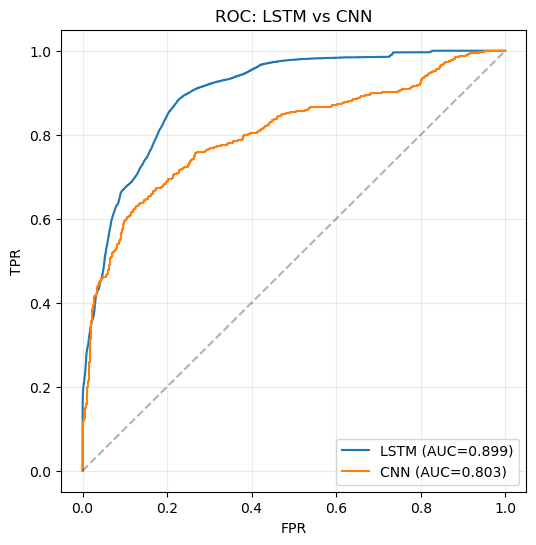

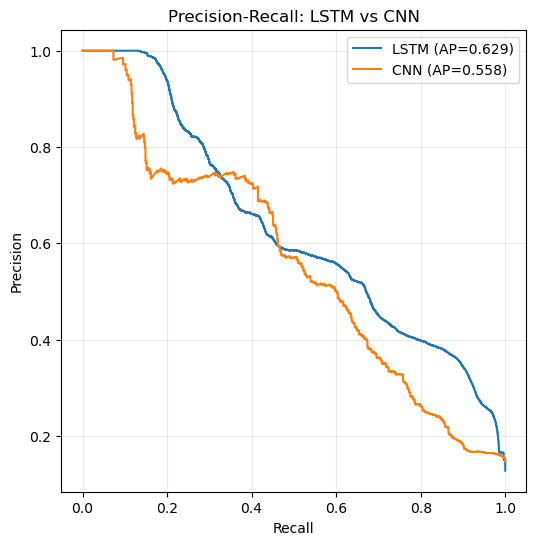

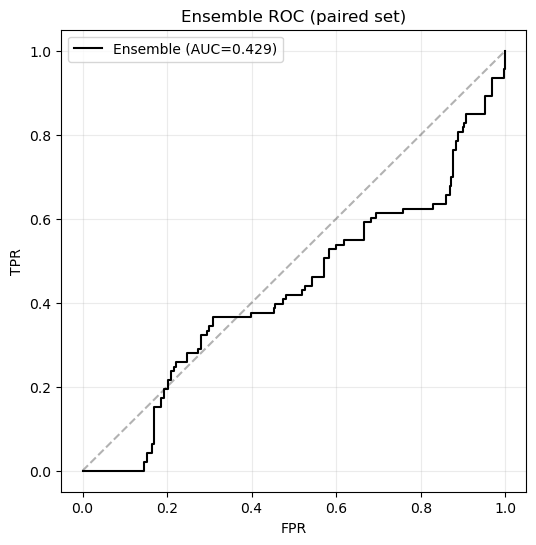

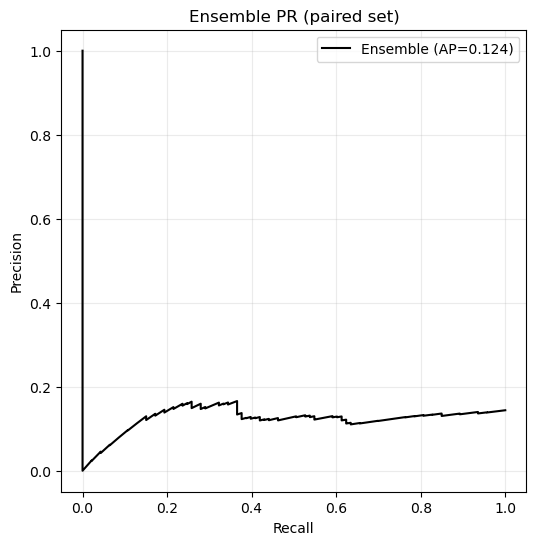


Done. Plots saved in: C:\Users\Owner\Onedrive\Desktop\solar_proj\models


In [7]:

import numpy as np, os, joblib
from pathlib import Path
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

ROOT = Path(r"C:\Users\Owner\Onedrive\Desktop\solar_proj")
MODELS = ROOT / "models"
DATA = ROOT / "data"


def find_existing(dirp, candidates):
    for n in candidates:
        p = dirp / n
        if p.exists(): return p
    return None

P_LSTM_path = find_existing(MODELS, ["P_LSTM.npy","P_lstm.npy","p_lstm.npy"])
P_CNN_path  = find_existing(MODELS, ["P_CNN.npy","P_cnn.npy","p_cnn.npy"])
y_path      = find_existing(MODELS, ["modelB_y.npy","modelB_y_all.npy","y_all.npy","y.npy","modelB_y.npy"])
matched_path= find_existing(MODELS, ["matched_seq_to_cnn_pairs.npy","matched_seq_to_cnn_pairs.npy"])
ensemble_path = find_existing(MODELS, ["ensemble_logreg.pkl","ensemble_logreg.pkl"])
roc_json = find_existing(MODELS, ["roc_pr_summary.json","roc_pr_summary.json"])

# Check
print("Found:")
print(" P_LSTM:", P_LSTM_path)
print(" P_CNN :", P_CNN_path)
print(" y_all :", y_path)
print(" matched:", matched_path)
print(" ensemble:", ensemble_path)
print(" roc_json:", roc_json)
print()

# Must have P_LSTM and y at minimum
if P_LSTM_path is None or y_path is None:
    raise FileNotFoundError("Missing required P_LSTM.npy or modelB_y.npy. Run the diagnostic cell and confirm filenames.")

# Load
P_LSTM = np.load(P_LSTM_path)
y_all  = np.load(y_path)

# Load CNN probs if present
P_CNN = None
if P_CNN_path:
    P_CNN = np.load(P_CNN_path)
    print("Loaded P_CNN shape:", P_CNN.shape)
else:
    print("P_CNN not found — CNN curves will be built from matched pairs only if possible.")

# Load matched pairs
if matched_path and matched_path.exists():
    matched = np.load(matched_path, allow_pickle=True)
    matched = np.asarray(matched, dtype=int)
    print("Loaded matched pairs:", matched.shape)
else:
    matched = None
    print("No matched_pairs file found.")

# Try to recover CNN labels for the cnn_index (if final_cnn_dataset.csv exists)
cnn_csv = ROOT / "final_cnn_dataset.csv"
cnn_labels = None
if P_CNN is not None:
    if cnn_csv.exists():
        import pandas as pd
        df_cnn = pd.read_csv(cnn_csv)
        # expected final_cnn_dataset.csv has rows aligned to cnn_index; but to be safe check length
        if len(df_cnn) == len(P_CNN):
            try:
                cnn_labels = df_cnn["label_MX_24h"].values.astype(int)
                print("Recovered cnn_labels from final_cnn_dataset.csv (len matches P_CNN).")
            except Exception:
                cnn_labels = None
        else:
            print("final_cnn_dataset.csv length != P_CNN length; not using csv labels directly.")
    else:
        print("final_cnn_dataset.csv not present; CNN full-label ROC will be computed on matched subset only.")


fpr_l, tpr_l, _ = roc_curve(y_all, P_LSTM)
auc_l = auc(fpr_l, tpr_l)
prec_l, rec_l, _ = precision_recall_curve(y_all, P_LSTM)
ap_l = auc(rec_l, prec_l)
print(f"LSTM (all) -> samples: {len(y_all)} AUC={auc_l:.4f} AP={ap_l:.4f}")


fpr_c = tpr_c = prec_c = rec_c = None
auc_c = ap_c = None
if P_CNN is not None:
    if cnn_labels is not None:
        fpr_c, tpr_c, _ = roc_curve(cnn_labels, P_CNN)
        auc_c = auc(fpr_c, tpr_c)
        prec_c, rec_c, _ = precision_recall_curve(cnn_labels, P_CNN)
        ap_c = auc(rec_c, prec_c)
        print(f"CNN (full) -> samples: {len(cnn_labels)} AUC={auc_c:.4f} AP={ap_c:.4f}")
    elif matched is not None:

        cnn_idxs = matched[:,1]
        seq_idxs = matched[:,0]
        valid = (cnn_idxs >= 0)
        cnn_idxs = cnn_idxs[valid]; seq_idxs = seq_idxs[valid]
        if len(cnn_idxs)==0:
            print("No valid matched pairs to compute CNN ROC.")
        else:
            labels_m = y_all[seq_idxs]
            pcnn_m = P_CNN[cnn_idxs]
            fpr_c, tpr_c, _ = roc_curve(labels_m, pcnn_m)
            auc_c = auc(fpr_c, tpr_c)
            prec_c, rec_c, _ = precision_recall_curve(labels_m, pcnn_m)
            ap_c = auc(rec_c, prec_c)
            print(f"CNN (matched subset) -> samples: {len(labels_m)} AUC={auc_c:.4f} AP={ap_c:.4f}")
    else:
        print("No method to compute CNN metrics (no csv labels, no matched pairs).")
else:
    print("P_CNN not present — skipping CNN metrics.")


X_pair = None; y_pair = None; ens_probs = None
if matched is not None:
    valid = matched[:,1] >= 0
    matched_used = matched[valid]
    seq_idxs = matched_used[:,0].astype(int)
    cnn_idxs = matched_used[:,1].astype(int)
    # build X_pair: columns [P_LSTM(seq_idx), P_CNN(cnn_idx)]
    if P_CNN is None:
        raise RuntimeError("Need P_CNN.npy to build ensemble dataset from matched pairs.")
    X_pair = np.vstack([P_LSTM[seq_idxs], P_CNN[cnn_idxs]]).T
    y_pair = y_all[seq_idxs].astype(int)
    print("Paired dataset size:", X_pair.shape, "labels:", np.bincount(y_pair))

    # load saved ensemble model if present
    if ensemble_path and ensemble_path.exists():
        ens = joblib.load(ensemble_path)
        try:
            ens_probs = ens.predict_proba(X_pair)[:,1]
            print("Loaded ensemble model and computed probs on paired set.")
        except Exception as e:
            print("Failed to use loaded ensemble model:", e)
            ens = None
    else:
        ens = None

    # if no saved ensemble or load failed -> train fresh logistic on a train/val split (stratified)
    if ens is None:
        from sklearn.model_selection import train_test_split
        trX, vX, try_, vy = train_test_split(X_pair, y_pair, test_size=0.25, stratify=y_pair, random_state=42)
        lr = LogisticRegression(max_iter=2000)
        try:
            lr.fit(trX, try_)
            ens = lr
            ens_probs = ens.predict_proba(vX)[:,1]
            print("Trained fresh logistic on matched pairs (used val set).")
            # Save model so next run loads it
            joblib.dump(ens, MODELS/"ensemble_logreg.pkl")
            # Put vX/vy aside for validation plots below
            X_pair_val, y_pair_val = vX, vy
        except Exception as e:
            print("Failed to train logistic:", e)
else:
    print("No matched pairs -> cannot compute ensemble metrics.")


if ens is not None and ens_probs is None and X_pair is not None:
    ens_probs = ens.predict_proba(X_pair)[:,1]
    # assume we'll evaluate on full X_pair
    X_pair_val, y_pair_val = X_pair, y_pair


out_dir = MODELS
def save_and_show_fig(fig, fname):
    p = out_dir / fname
    fig.savefig(p, dpi=200, bbox_inches="tight")
    print("Saved:", p)
    plt.show()


plt.figure(figsize=(6,6))
plt.plot(fpr_l, tpr_l, label=f"LSTM (AUC={auc_l:.3f})")
if fpr_c is not None:
    plt.plot(fpr_c, tpr_c, label=f"CNN (AUC={auc_c:.3f})")
plt.plot([0,1],[0,1],'k--',alpha=0.3)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC: LSTM vs CNN")
plt.legend(); plt.grid(alpha=0.25)
plt.savefig(out_dir/"roc_lstm_cnn.png", dpi=200); plt.show()

# 2) PR curves LSTM vs CNN
plt.figure(figsize=(6,6))
plt.plot(rec_l, prec_l, label=f"LSTM (AP={ap_l:.3f})")
if prec_c is not None:
    plt.plot(rec_c, prec_c, label=f"CNN (AP={ap_c:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall: LSTM vs CNN")
plt.legend(); plt.grid(alpha=0.25)
plt.savefig(out_dir/"pr_lstm_cnn.png", dpi=200); plt.show()

# 3) Ensemble ROC+PR (on paired set)
if ens is not None and ens_probs is not None:
    if 'y_pair_val' not in locals():
        X_pair_val, y_pair_val = X_pair, y_pair
    fpr_e, tpr_e, _ = roc_curve(y_pair_val, ens.predict_proba(X_pair_val)[:,1])
    auc_e = auc(fpr_e, tpr_e)
    prec_e, rec_e, _ = precision_recall_curve(y_pair_val, ens.predict_proba(X_pair_val)[:,1])
    ap_e = auc(rec_e, prec_e)

    plt.figure(figsize=(6,6))
    plt.plot(fpr_e, tpr_e, label=f"Ensemble (AUC={auc_e:.3f})", color="black")
    plt.plot([0,1],[0,1],'k--',alpha=0.3)
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Ensemble ROC (paired set)")
    plt.legend(); plt.grid(alpha=0.25)
    plt.savefig(out_dir/"roc_ensemble.png", dpi=200); plt.show()

    plt.figure(figsize=(6,6))
    plt.plot(rec_e, prec_e, label=f"Ensemble (AP={ap_e:.3f})", color="black")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Ensemble PR (paired set)")
    plt.legend(); plt.grid(alpha=0.25)
    plt.savefig(out_dir/"pr_ensemble.png", dpi=200); plt.show()

print("\nDone. Plots saved in:", out_dir)
